# 1. Double LoRA Pipeline

In my first test, I implement a double LoRA design to specialize an LLM in motif extraction from conspiracy messages. For the first set of LoRA, I rely on the (extended) FrameNet dataset, a set of Q&A examples for the analysis of frames through verbs and associated actors ([hugginface repository](https://huggingface.co/datasets/shahidrai/All_FrameNet_extended)). Fine-tuning is then extended using data from my corpus of conspiracy messages, which should make the LLM more attuned to examples of highly idiosyncratic conspiracy language which it is unlikely to have encountered during its original training for safety reasons. 

## Imports and setup

In [1]:
!pip install transformers accelerate datasets bitsandbytes peft -q
!pip -q install gdown

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import transformers
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
)
from transformers import DataCollatorForLanguageModeling

from peft import LoraConfig, get_peft_model, TaskType, PeftModel

from datasets import load_dataset, Dataset, DatasetDict

import os
import numpy as np
import pandas as pd
import time

print("All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 43.0 MB/s eta 0:00:00:00:0100:01
All libraries imported successfully!


In [2]:
MODEL_NAME = "facebook/galactica-125m"
print(f"Using model: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16
)

print("Base model loaded!")

Using model: facebook/galactica-125m


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/787 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/250M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Base model loaded!


## LoRA 1: FrameNet

In [3]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["k_proj", "q_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model_lora = get_peft_model(base_model, lora_config)
print("LoRA configuration applied!")
model_lora.print_trainable_parameters()

LoRA configuration applied!
trainable params: 442,368 || all params: 125,472,768 || trainable%: 0.3526


In [4]:
print("Loading FrameNet dataset...")
raw_dataset = load_dataset("shahidrai/All_FrameNet_extended")
print(raw_dataset)
print(f"\nDataset structure: {raw_dataset['train'].features}")
print(f"Sample example:\nQuestion: {raw_dataset['train'][0]['Question'][:200]}...")
print(f"Answer: {raw_dataset['train'][0]['Answer'][:100]}...")

# Sample 1% of the entire dataset
sampled_dataset = raw_dataset['train'].train_test_split(test_size=0.99, seed=42)
sampled_data = sampled_dataset['train']
print(f"\nSampled 1% of dataset: {len(sampled_data)} examples")

# Split into train/val/test (80%/10%/10%)
train_val_test = sampled_data.train_test_split(test_size=0.2, seed=42)
train_data = train_val_test['train']
val_test = train_val_test['test'].train_test_split(test_size=0.5, seed=42)
val_data = val_test['train']
test_data = val_test['test']

framenet_dataset = DatasetDict({
    'train': train_data,
    'validation': val_data,
    'test': test_data
})

print(f"\nFrameNet dataset splits (1% of original):")
print(f"Train: {len(framenet_dataset['train'])} examples")
print(f"Validation: {len(framenet_dataset['validation'])} examples")
print(f"Test: {len(framenet_dataset['test'])} examples")

Loading FrameNet dataset...


json_train.json:   0%|          | 0.00/761M [00:00<?, ?B/s]

val.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1679741 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Question', 'Answer'],
        num_rows: 1679741
    })
    validation: Dataset({
        features: ['Question', 'Answer'],
        num_rows: 500
    })
})

Dataset structure: {'Question': Value('string'), 'Answer': Value('string')}
Sample example:
Question: Can you describe what typically happens in the "Suspicion" frame? What kind of situation or event does the Suspicion frame represent?...
Answer: The "Suspicion" frame represents a type of situation or event in which specific participants (called...

Sampled 1% of dataset: 16797 examples

FrameNet dataset splits (1% of original):
Train: 13437 examples
Validation: 1680 examples
Test: 1680 examples


In [5]:
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
model_lora.resize_token_embeddings(len(tokenizer))

def tokenize_function_framenet(example):
    texts = [f"Question: {q}\nAnswer: {a}" for q, a in zip(example["Question"], example["Answer"])]
    return tokenizer(texts, truncation=True, padding="max_length", max_length=256)

tokenized_framenet = framenet_dataset.map(
    tokenize_function_framenet, 
    batched=True, 
    num_proc=1, 
    remove_columns=["Question", "Answer"]
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

print("FrameNet dataset tokenized!")

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Map:   0%|          | 0/13437 [00:00<?, ? examples/s]

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

FrameNet dataset tokenized!


In [6]:
print("\n" + "="*80)
print("STAGE 1: Training LoRA on FrameNet Dataset")
print("="*80 + "\n")

training_args_framenet = TrainingArguments(
    output_dir="lora-framenet-checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=3,
    logging_steps=50,
    fp16=True,
    report_to="none",
    max_grad_norm=1.0,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
)


trainer_framenet = Trainer(
    model=model_lora,
    args=training_args_framenet,
    train_dataset=tokenized_framenet["train"],
    eval_dataset=tokenized_framenet["validation"],
    data_collator=data_collator,
)

trainer_framenet.train()
print("\nFrameNet LoRA training complete!")

# Evaluate FrameNet LoRA
eval_results_framenet = trainer_framenet.evaluate()
print("\n" + "="*80)
print("FrameNet LoRA Evaluation Results:")
print("="*80)
print(eval_results_framenet)
framenet_loss = eval_results_framenet["eval_loss"]
framenet_ppl = np.exp(framenet_loss)
print(f"FrameNet Validation Loss: {framenet_loss:.4f}")
print(f"FrameNet Validation Perplexity: {framenet_ppl:.2f}")


STAGE 1: Training LoRA on FrameNet Dataset



Epoch,Training Loss,Validation Loss
1,1.328475,1.316666
2,1.350125,1.229490
3,1.199780,1.194103


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(



FrameNet LoRA training complete!



FrameNet LoRA Evaluation Results:
{'eval_loss': 1.1941014528274536, 'eval_runtime': 17.9231, 'eval_samples_per_second': 93.734, 'eval_steps_per_second': 46.867, 'epoch': 3.0}
FrameNet Validation Loss: 1.1941
FrameNet Validation Perplexity: 3.30


## LoRA 2: Conspiracy Messages

In [7]:
!gdown --fuzzy "https://drive.google.com/file/d/1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H/view?usp=sharing" -O /content/original_content_en_1mio.csv

path = "/content/original_content_en_1mio.csv"
messages = pd.read_csv(path)
print(f"Loaded {len(messages)} Telegram messages")

# Extract handcoded test samples
test_ids = [8142176, 7130377, 18556553, 35168422, 33729614, 7599732, 36858681, 7221875, 36023073, 36890846, 35692943]
test_messages = messages[messages['posts_id'].isin(test_ids)].copy()
print(f"Test set: {len(test_messages)} handcoded messages")

# Sample 2% of dataset (20k messages) for training, excluding test samples
train_messages = messages[~messages['posts_id'].isin(test_ids)].copy()
target_sample_size = 20000
actual_sample_size = min(target_sample_size, len(train_messages))
train_sample = train_messages.sample(n=actual_sample_size, random_state=42)
print(f"Training set: {len(train_sample)} messages (2% of original dataset)")

Downloading...
From (original): https://drive.google.com/uc?id=1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H
From (redirected): https://drive.google.com/uc?id=1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H&confirm=t&uuid=ecf7c7a8-41dc-4009-b7e2-bd5927d0c4ae
To: /content/original_content_en_1mio.csv
100% 364M/364M [00:07<00:00, 45.7MB/s] 
Loaded 1000000 Telegram messages
Test set: 11 handcoded messages
Training set: 20000 messages (2% of original dataset)


In [8]:
# Prepare conspiracy messages as plain text (no Q&A format)
print(f"Processing {len(train_sample)} conspiracy messages...")
conspiracy_texts = []

for idx, row in train_sample.iterrows():
    message = str(row['content'])
    if len(message.strip()) > 20:  # Only process meaningful messages
        conspiracy_texts.append({'text': message})
    
    if len(conspiracy_texts) % 5000 == 0 and len(conspiracy_texts) > 0:
        print(f"Processed {len(conspiracy_texts)} messages...")

print(f"\nTotal messages prepared: {len(conspiracy_texts)}")
print(f"Sample message:")
print(f"{conspiracy_texts[0]['text'][:200]}...")

# Create dataset
conspiracy_df = pd.DataFrame(conspiracy_texts)
conspiracy_dataset_full = Dataset.from_pandas(conspiracy_df)

# Split into train/val (80/20)
conspiracy_split = conspiracy_dataset_full.train_test_split(test_size=0.2, seed=42)
conspiracy_dataset = DatasetDict({
    'train': conspiracy_split['train'],
    'validation': conspiracy_split['test']
})

print(f"\nConspiracy dataset splits:")
print(f"Train: {len(conspiracy_dataset['train'])} examples")
print(f"Validation: {len(conspiracy_dataset['validation'])} examples")

Processing 20000 conspiracy messages...
Processed 5000 messages...
Processed 10000 messages...
Processed 15000 messages...
Processed 20000 messages...

Total messages prepared: 20000
Sample message:
Thank you! All truth, and I think our patriots  just needed to take time to look at the full picture. I watched Derik Johnson after the speech last night just readjust my attitude! So many thought Tru...

Conspiracy dataset splits:
Train: 16000 examples
Validation: 4000 examples


In [9]:
def tokenize_function_conspiracy(example):
    # Tokenize plain text messages for causal language modeling
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=512  # Longer context for full messages
    )

tokenized_conspiracy = conspiracy_dataset.map(
    tokenize_function_conspiracy,
    batched=True,
    num_proc=1,
    remove_columns=["text"]
)

print("Conspiracy dataset tokenized!")

training_args_conspiracy = TrainingArguments(
    output_dir="lora-conspiracy-checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=2,
    logging_steps=25,
    fp16=True,
    report_to="none",
    max_grad_norm=1.0,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
)

trainer_conspiracy = Trainer(
    model=model_lora,
    args=training_args_conspiracy,
    train_dataset=tokenized_conspiracy["train"],
    eval_dataset=tokenized_conspiracy["validation"],
    data_collator=data_collator,
)

trainer_conspiracy.train()
print("\nConspiracy Messages LoRA training complete!")

# Evaluate Conspiracy LoRA
eval_results_conspiracy = trainer_conspiracy.evaluate()
print("\n" + "="*80)
print("Conspiracy Messages LoRA Evaluation Results:")
print("="*80)
print(eval_results_conspiracy)
conspiracy_loss = eval_results_conspiracy["eval_loss"]
conspiracy_ppl = np.exp(conspiracy_loss)
print(f"Conspiracy Validation Loss: {conspiracy_loss:.4f}")
print(f"Conspiracy Validation Perplexity: {conspiracy_ppl:.2f}")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Conspiracy dataset tokenized!


Epoch,Training Loss,Validation Loss
1,3.867186,3.870486
2,3.721767,3.821095


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(



Conspiracy Messages LoRA training complete!



Conspiracy Messages LoRA Evaluation Results:
{'eval_loss': 3.8210957050323486, 'eval_runtime': 48.475, 'eval_samples_per_second': 82.517, 'eval_steps_per_second': 41.258, 'epoch': 2.0}
Conspiracy Validation Loss: 3.8211
Conspiracy Validation Perplexity: 45.65


## Testing and Comparison

In [13]:
def extract_action_motif(message, model, tokenizer, max_new_tokens=100):
    prompt = f"Question: Extract the action motif (who does what to whom) from: {message}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Answer:" in full_text:
        answer = full_text.split("Answer:")[-1].strip()
    else:
        answer = full_text[len(prompt):].strip()
    
    return answer

# Test on handcoded messages
print("Testing on handcoded conspiracy messages:")
print("Results below are for qualitative inspection\n")

results = []
for i, (idx, row) in enumerate(test_messages.iterrows(), 1):
    message = str(row['content'])[:500]
    print(f"\n{'='*80}")
    print(f"TEST MESSAGE {i}/{len(test_messages)} - ID: {row['posts_id']}")
    print(f"{'='*80}")
    print(f"\nOriginal Message:")
    print(f"{message[:300]}..." if len(message) > 300 else message)
    
    extracted_motif = extract_action_motif(message, model_lora, tokenizer)
    print(f"\nExtracted Action Motif:")
    print(f"{extracted_motif}")
    
    results.append({
        'id': row['posts_id'],
        'message': message,
        'extracted_motif': extracted_motif
    })

print(f"Completed extraction for {len(results)} test messages")

Testing on handcoded conspiracy messages:
Results below are for qualitative inspection


TEST MESSAGE 1/11 - ID: 8142176

Original Message:
YOU'VE BEEN SELECTED TO GET YOUR VERY OWN TRUMP BUCKS TODAY!!!
💥Makes the PERFECT Gift for other Trump Loving Patriots!
💥A Great Collectible Item to Celebrate President Trump's Historic Legacy.
💥About 74 million Americans are Trump supporters so if you’re looking for an item that will be loved by ev...

Extracted Action Motif:
https://t.me/+XkXkQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQz

TEST MESSAGE 2/11 - ID: 7130377

Original Message:
Real America with Dan Ball has a new set design launching Monday May 23rd as Dan interviews President Donald J. Trump! 🇺🇸🎉

Tune in to OAN 8 pm ET / 5 pm PT

Dan’s set > Brandon’s fake set

Today will be a new day.🇺🇸
Join me here:👇
@RealDonaldTrump_Potus

Extracted Action Motif:
@RealDonaldTrump_Potus

@RealDonaldTrump_Potus
https://t.me/RealDonaldTrump_Potus

@RealDonald

In [14]:
print("Model Architecture:")
print(f"  Base Model: {MODEL_NAME}")
print(f"  LoRA Config: r={lora_config.r}, alpha={lora_config.lora_alpha}")
print(f"  Target Modules: {lora_config.target_modules}")

print("\nStage 1 - FrameNet LoRA:")
print(f"  Validation Loss: {framenet_loss:.4f}")
print(f"  Validation Perplexity: {framenet_ppl:.2f}")
print(f"  Training Examples: {len(tokenized_framenet['train'])}")
print(f"  Epochs: {training_args_framenet.num_train_epochs}")

print("\nStage 2 - Conspiracy Messages LoRA:")
print(f"  Validation Loss: {conspiracy_loss:.4f}")
print(f"  Validation Perplexity: {conspiracy_ppl:.2f}")
print(f"  Training Examples: {len(tokenized_conspiracy['train'])} (plain text messages)")
print(f"  Epochs: {training_args_conspiracy.num_train_epochs}")
print(f"  Format: Direct text fine-tuning (not Q&A)")

print("\nTest Set:")
print(f"  {len(test_messages)} handcoded conspiracy messages")
print(f"  Evaluation: Qualitative inspection of extracted action motifs")

# print("\nModel Saved:")
# print(f"  Location: {model_save_path}")
# print(f"  Components: LoRA adapters + tokenizer")

print("\n" + "="*80)
print("PIPELINE COMPLETE!")
print("="*80)
print("\nThe model has been fine-tuned sequentially on:")
print("1. FrameNet dataset (general action motif extraction task via Q&A)")
print("2. Conspiracy messages (domain adaptation via plain text, 20k messages)")
print("\nThe dual approach combines:")
print("  - Task learning (action motif extraction) from FrameNet")
print("  - Domain knowledge (conspiracy language/style) from plain text")
print("\nTested on handcoded conspiracy messages for qualitative evaluation.")
print("Model is saved and ready for future use.")

Model Architecture:
  Base Model: facebook/galactica-125m
  LoRA Config: r=8, alpha=32
  Target Modules: {'k_proj', 'v_proj', 'q_proj', 'o_proj'}

Stage 1 - FrameNet LoRA:
  Validation Loss: 1.1941
  Validation Perplexity: 3.30
  Training Examples: 13437
  Epochs: 3

Stage 2 - Conspiracy Messages LoRA:
  Validation Loss: 3.8211
  Validation Perplexity: 45.65
  Training Examples: 16000 (plain text messages)
  Epochs: 2
  Format: Direct text fine-tuning (not Q&A)

Test Set:
  11 handcoded conspiracy messages
  Evaluation: Qualitative inspection of extracted action motifs

PIPELINE COMPLETE!

The model has been fine-tuned sequentially on:
1. FrameNet dataset (general action motif extraction task via Q&A)
2. Conspiracy messages (domain adaptation via plain text, 20k messages)

The dual approach combines:
  - Task learning (action motif extraction) from FrameNet
  - Domain knowledge (conspiracy language/style) from plain text

Tested on handcoded conspiracy messages for qualitative evaluati

In [15]:
# Handcoded motifs for the test messages
# Format: list of dicts with "actor" and "action" keys
handcoded_motifs = [
    [],  # Message 0
    [],  # Message 1
    [],  # Message 2
    [    # Message 3 (ID: 35168422)
        {"actor": "Trump", "action": "confirm"},
        {"actor": "Trump", "action": "release"},
        {"actor": "Trump", "action": "post"},
        {"actor": "Trump", "action": "promise"}
    ],
    [],  # Message 4
    [],  # Message 5
    [    # Message 6 (ID: 36858681)
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "say"},
        {"actor": "Trump", "action": "sign"}
    ],
    [    # Message 7 (ID: 7221875)
        {"actor": "Trump", "action": "have"},
        {"actor": "Trump", "action": "post"}
    ],
    [    # Message 8 (ID: 36023073)
        {"actor": "Trump", "action": "do"},
        {"actor": "Trump", "action": "help"},
        {"actor": "Trump", "action": "give away"}
    ],
    [    # Message 9 (ID: 36890846)
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "say"},
        {"actor": "Trump", "action": "say"}
    ],
    [    # Message 10 (ID: 35692943)
        {"actor": "Trump", "action": "go"},
        {"actor": "Trump", "action": "come back"},
        {"actor": "Trump", "action": "talk"}
    ]
]

# Add handcoded labels to test_messages dataframe
test_messages_with_labels = test_messages.copy()
test_messages_with_labels['handcoded_motifs'] = handcoded_motifs

print(f"Loaded handcoded labels for {len(test_messages_with_labels)} messages")
print(f"Messages with non-empty labels: {sum(1 for m in handcoded_motifs if len(m) > 0)}")
print(f"Total handcoded motifs: {sum(len(m) for m in handcoded_motifs)}")

Loaded handcoded labels for 11 messages
Messages with non-empty labels: 6
Total handcoded motifs: 20


In [16]:
import re

def parse_motifs_from_text(text):
    """
    Parse action motifs from LLM output text.
    Attempts to extract actor-action pairs using various patterns.
    """
    motifs = []
    
    # Clean the text
    text = text.strip()
    
    # Pattern 1: "Actor does/did action"
    pattern1 = r'(\w+(?:\s+\w+)?)\s+(?:does|did|will|is|was|has|have)\s+([^.;,]+)'
    matches1 = re.findall(pattern1, text, re.IGNORECASE)
    for actor, action in matches1:
        motifs.append({"actor": actor.strip(), "action": action.strip()})
    
    # Pattern 2: "Actor: action" or "Actor - action"
    pattern2 = r'(\w+(?:\s+\w+)?):\s*([^.;,\n]+)'
    matches2 = re.findall(pattern2, text)
    for actor, action in matches2:
        motifs.append({"actor": actor.strip(), "action": action.strip()})
    
    # Pattern 3: Simple "Actor action" (noun-verb pattern)
    # Look for capitalized words followed by verbs
    pattern3 = r'\b([A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)\s+((?:confirm|release|post|promise|sign|say|have|do|help|give|go|come|talk|make|take|get|want|need|try|use|tell|show|find|know|think|believe|see|call|ask|work|seem|feel|leave|put|mean|keep|let|begin|start|write|turn|run|move|like|bring|happen|hold|understand|watch|follow|stop|create|speak|read|allow|add|spend|grow|open|walk|win|offer|remember|consider|appear|buy|wait|serve|die|send|build|stay|fall|cut|reach|kill|remain|suggest|raise|pass|report|decide|pull|accept|require|continue|lose|argue|expect|support|claim)[a-z]*)\b'
    matches3 = re.findall(pattern3, text, re.IGNORECASE)
    for actor, action in matches3:
        motifs.append({"actor": actor.strip(), "action": action.strip()})
    
    return motifs

# Extract motifs for each test message
llm_extractions = []

for idx, row in test_messages_with_labels.iterrows():
    message = str(row['content'])[:500]
    
    # Get LLM extraction
    extracted_text = extract_action_motif(message, model_lora, tokenizer, max_new_tokens=150)
    
    # Parse motifs from extraction
    parsed_motifs = parse_motifs_from_text(extracted_text)
    
    llm_extractions.append({
        'message_id': row['posts_id'],
        'raw_extraction': extracted_text,
        'parsed_motifs': parsed_motifs,
        'handcoded_motifs': row['handcoded_motifs']
    })

print(f"Completed extraction for {len(llm_extractions)} messages\n")

Completed extraction for 11 messages



In [17]:
def compare_motifs(llm_motifs, handcoded_motifs):
    """
    Compare LLM-extracted motifs with handcoded motifs.
    Returns precision, recall, F1 for actors and actions.
    """
    # Extract sets for comparison
    llm_actors = set([m['actor'].lower() for m in llm_motifs])
    llm_actions = set([m['action'].lower() for m in llm_motifs])
    
    gold_actors = set([m['actor'].lower() for m in handcoded_motifs])
    gold_actions = set([m['action'].lower() for m in handcoded_motifs])
    
    # Actor metrics
    actor_tp = len(llm_actors & gold_actors)
    actor_fp = len(llm_actors - gold_actors)
    actor_fn = len(gold_actors - llm_actors)
    
    actor_precision = actor_tp / (actor_tp + actor_fp) if (actor_tp + actor_fp) > 0 else 0
    actor_recall = actor_tp / (actor_tp + actor_fn) if (actor_tp + actor_fn) > 0 else 0
    actor_f1 = 2 * actor_precision * actor_recall / (actor_precision + actor_recall) if (actor_precision + actor_recall) > 0 else 0
    
    # Action metrics (with partial matching)
    action_tp = 0
    for llm_action in llm_actions:
        for gold_action in gold_actions:
            if llm_action in gold_action or gold_action in llm_action:
                action_tp += 1
                break
    
    action_fp = len(llm_actions) - action_tp
    action_fn = len(gold_actions) - action_tp
    
    action_precision = action_tp / (action_tp + action_fp) if (action_tp + action_fp) > 0 else 0
    action_recall = action_tp / (action_tp + action_fn) if (action_tp + action_fn) > 0 else 0
    action_f1 = 2 * action_precision * action_recall / (action_precision + action_recall) if (action_precision + action_recall) > 0 else 0
    
    return {
        'actor_precision': actor_precision,
        'actor_recall': actor_recall,
        'actor_f1': actor_f1,
        'action_precision': action_precision,
        'action_recall': action_recall,
        'action_f1': action_f1,
        'llm_count': len(llm_motifs),
        'gold_count': len(handcoded_motifs)
    }

# Calculate metrics for each message and aggregate
all_metrics = []
messages_with_labels = 0

for extraction in llm_extractions:
    if len(extraction['handcoded_motifs']) > 0:
        messages_with_labels += 1
        metrics = compare_motifs(extraction['parsed_motifs'], extraction['handcoded_motifs'])
        metrics['message_id'] = extraction['message_id']
        all_metrics.append(metrics)

# Aggregate metrics
if all_metrics:
    avg_actor_precision = np.mean([m['actor_precision'] for m in all_metrics])
    avg_actor_recall = np.mean([m['actor_recall'] for m in all_metrics])
    avg_actor_f1 = np.mean([m['actor_f1'] for m in all_metrics])
    
    avg_action_precision = np.mean([m['action_precision'] for m in all_metrics])
    avg_action_recall = np.mean([m['action_recall'] for m in all_metrics])
    avg_action_f1 = np.mean([m['action_f1'] for m in all_metrics])
    
    print("AGGREGATE METRICS (averaged across messages with labels)")
    print(f"Messages evaluated: {messages_with_labels}")
    print("\nActor Extraction:")
    print(f"  Precision: {avg_actor_precision:.3f}")
    print(f"  Recall:    {avg_actor_recall:.3f}")
    print(f"  F1 Score:  {avg_actor_f1:.3f}")
    
    print("\nAction Extraction (partial match):")
    print(f"  Precision: {avg_action_precision:.3f}")
    print(f"  Recall:    {avg_action_recall:.3f}")
    print(f"  F1 Score:  {avg_action_f1:.3f}")
    
    print("\n" + "-"*80)
    print("PER-MESSAGE METRICS:")
    print("-"*80)
    for m in all_metrics:
        print(f"\nMessage ID: {m['message_id']}")
        print(f"  LLM extracted: {m['llm_count']} motifs | Handcoded: {m['gold_count']} motifs")
        print(f"  Actor F1: {m['actor_f1']:.3f} | Action F1: {m['action_f1']:.3f}")
else:
    print("No messages with handcoded labels to evaluate.")

AGGREGATE METRICS (averaged across messages with labels)
Messages evaluated: 6

Actor Extraction:
  Precision: 0.000
  Recall:    0.000
  F1 Score:  0.000

Action Extraction (partial match):
  Precision: 0.000
  Recall:    0.000
  F1 Score:  0.000

--------------------------------------------------------------------------------
PER-MESSAGE METRICS:
--------------------------------------------------------------------------------

Message ID: 35168422
  LLM extracted: 2 motifs | Handcoded: 4 motifs
  Actor F1: 0.000 | Action F1: 0.000

Message ID: 36858681
  LLM extracted: 1 motifs | Handcoded: 4 motifs
  Actor F1: 0.000 | Action F1: 0.000

Message ID: 7221875
  LLM extracted: 1 motifs | Handcoded: 2 motifs
  Actor F1: 0.000 | Action F1: 0.000

Message ID: 36023073
  LLM extracted: 1 motifs | Handcoded: 3 motifs
  Actor F1: 0.000 | Action F1: 0.000

Message ID: 36890846
  LLM extracted: 1 motifs | Handcoded: 4 motifs
  Actor F1: 0.000 | Action F1: 0.000

Message ID: 35692943
  LLM extrac

In [18]:
for i, extraction in enumerate(llm_extractions, 1):
    message_id = extraction['message_id']
    raw_extraction = extraction['raw_extraction']
    llm_motifs = extraction['parsed_motifs']
    gold_motifs = extraction['handcoded_motifs']
    
    # Get original message
    orig_message = test_messages_with_labels[test_messages_with_labels['posts_id'] == message_id]['content'].values[0]
    
    print(f"\n{'='*80}")
    print(f"MESSAGE {i}/{len(llm_extractions)} - ID: {message_id}")
    print(f"{'='*80}")
    
    print(f"\nOriginal Message:")
    print(f"{str(orig_message)[:300]}...")
    
    print(f"\n{'-'*80}")
    print("LLM RAW OUTPUT:")
    print(f"{'-'*80}")
    print(raw_extraction)
    
    print(f"\n{'-'*40}")
    print("PARSED LLM MOTIFS:")
    print(f"{'-'*40}")
    if llm_motifs:
        for j, motif in enumerate(llm_motifs, 1):
            print(f"  {j}. Actor: {motif['actor']:15s} | Action: {motif['action']}")
    else:
        print("  (no motifs extracted)")
    
    print(f"\n{'-'*40}")
    print("HANDCODED MOTIFS (GROUND TRUTH):")
    print(f"{'-'*40}")
    if gold_motifs:
        for j, motif in enumerate(gold_motifs, 1):
            print(f"  {j}. Actor: {motif['actor']:15s} | Action: {motif['action']}")
    else:
        print("  (no motifs labeled)")
    
    # Show comparison
    if gold_motifs:
        print(f"\n{'-'*40}")
        print("COMPARISON:")
        print(f"{'-'*40}")
        
        llm_actors = set([m['actor'].lower() for m in llm_motifs])
        gold_actors = set([m['actor'].lower() for m in gold_motifs])
        llm_actions = set([m['action'].lower() for m in llm_motifs])
        gold_actions = set([m['action'].lower() for m in gold_motifs])
        
        matched_actors = llm_actors & gold_actors
        missed_actors = gold_actors - llm_actors
        extra_actors = llm_actors - gold_actors
        
        print(f"Actors - Matched: {matched_actors if matched_actors else 'none'}")
        print(f"Actors - Missed: {missed_actors if missed_actors else 'none'}")
        print(f"Actors - Extra: {extra_actors if extra_actors else 'none'}")
        
        # Action comparison (partial)
        matched_actions = []
        for llm_act in llm_actions:
            for gold_act in gold_actions:
                if llm_act in gold_act or gold_act in llm_act:
                    matched_actions.append((llm_act, gold_act))
        
        print(f"\nActions - Partial Matches: {len(matched_actions)}/{len(gold_actions)}")
        if matched_actions:
            for llm_act, gold_act in matched_actions:
                print(f"  LLM: '{llm_act}' <-> Gold: '{gold_act}'")


MESSAGE 1/11 - ID: 8142176

Original Message:
YOU'VE BEEN SELECTED TO GET YOUR VERY OWN TRUMP BUCKS TODAY!!!
💥Makes the PERFECT Gift for other Trump Loving Patriots!
💥A Great Collectible Item to Celebrate President Trump's Historic Legacy.
💥About 74 million Americans are Trump supporters so if you’re looking for an item that will be loved by ev...

--------------------------------------------------------------------------------
LLM RAW OUTPUT:
--------------------------------------------------------------------------------
https://t.me/+XkXkQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQzQz

----------------------------------------
PARSED LLM MOTIFS:
----------------------------------------
  1. Actor: https           | Action: //t

----------------------------------------
HANDCODED MOTIFS (GROUND TRUTH):
----------------------------------------
  (no motifs labeled)

MESSAGE 2/11 - ID: 7130377

Orig

The fine-tuned LLM fails miserably to extract any relevant actors or actions. There may be several reasons for this, including the size of the model (LLM too weak), the lack of training samples (both FrameNet and QAnon messages), and the messiness of the QAnon data. At this point we may also wonder to what degree it may have _hurt_ the LLM to be finetuned on QAnon data, given how messy it is. Perhaps sticking to FrameNet would have been the safer bet in this scenario. 

# 2. Hybrid DSPy

## Imports and Setup

In [2]:
!pip install -q dspy-ai openai pandas numpy matplotlib scikit-learn sentence-transformers

import os
import json
import re
import ast
from typing import List, Dict, Any, Optional, Tuple
from dataclasses import dataclass, field
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

import dspy
from dspy.evaluate import Evaluate

## Config and Data Loading

In [3]:
@dataclass
class Config:
    """Configuration for the DSPy multi-LLM pipeline."""
    # OpenAI API configuration
    api_key: str = ""  # Set via environment variable or directly
    model: str = "gpt-4o-mini"
    
    # Pipeline settings
    num_cycles: int = 3  # Total number of refinement cycles
    max_deliberation_rounds: int = 12  # Max rounds for group discussion
    
    # Temperature settings
    prompt_engineer_temp: float = 0.7
    critic_temp: float = 0.5
    deliberation_temp: float = 0.6
    worker_temp: float = 0.3
    
    # Embedding model for visualization
    embedding_model: str = "all-MiniLM-L6-v2"


# Initialize config
config = Config()

# Set your API key
if not config.api_key:
    import getpass
    api_key = os.environ.get("OPENAI_API_KEY", "")
    if not api_key:
        api_key = getpass.getpass("Enter your OpenAI API key: ")
    config.api_key = api_key

# Configure DSPy with OpenAI
lm = dspy.LM(
    model=f"openai/{config.model}",
    api_key=config.api_key,
    temperature=config.prompt_engineer_temp
)
dspy.settings.configure(lm=lm)

print("DSPy configured with OpenAI")
print(f"  Model: {config.model}")

DSPy configured with OpenAI
  Model: gpt-4o-mini


In [4]:
!gdown --fuzzy "https://drive.google.com/file/d/1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H/view?usp=sharing" -O /content/original_content_en_1mio.csv

path = "/content/original_content_en_1mio.csv"
messages = pd.read_csv(path)
print(f"Loaded {len(messages)} Telegram messages")

# Extract handcoded test samples
sample_ids = [8142176, 7130377, 18556553, 35168422, 33729614, 7599732, 36858681, 7221875, 36023073, 36890846, 35692943]
sample = messages[messages['posts_id'].isin(sample_ids)].copy()

Downloading...
From (original): https://drive.google.com/uc?id=1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H
From (redirected): https://drive.google.com/uc?id=1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H&confirm=t&uuid=445e0b7d-f533-4e4e-a918-9c35926312e3
To: /content/original_content_en_1mio.csv
100% 364M/364M [00:05<00:00, 69.3MB/s] 
Loaded 1000000 Telegram messages


In [5]:
# Add motifs 
# Handcoded motifs for the test messages
# Format: list of dicts with "actor" and "action" keys
motifs = [
    [],  # Message 0
    [],  # Message 1
    [],  # Message 2
    [    # Message 3 (ID: 35168422)
        {"actor": "Trump", "action": "confirm"},
        {"actor": "Trump", "action": "release"},
        {"actor": "Trump", "action": "post"},
        {"actor": "Trump", "action": "promise"}
    ],
    [],  # Message 4
    [],  # Message 5
    [    # Message 6 (ID: 36858681)
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "say"},
        {"actor": "Trump", "action": "sign"}
    ],
    [    # Message 7 (ID: 7221875)
        {"actor": "Trump", "action": "have"},
        {"actor": "Trump", "action": "post"}
    ],
    [    # Message 8 (ID: 36023073)
        {"actor": "Trump", "action": "do"},
        {"actor": "Trump", "action": "help"},
        {"actor": "Trump", "action": "give away"}
    ],
    [    # Message 9 (ID: 36890846)
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "say"},
        {"actor": "Trump", "action": "say"}
    ],
    [    # Message 10 (ID: 35692943)
        {"actor": "Trump", "action": "go"},
        {"actor": "Trump", "action": "come back"},
        {"actor": "Trump", "action": "talk"}
    ]
]

# Add handcoded labels to test_messages dataframe
sample['motifs'] = motifs

print(f"Loaded handcoded labels for {len(sample)} messages")
print(f"Messages with non-empty labels: {sum(1 for m in motifs if len(m) > 0)}")
print(f"Total handcoded motifs: {sum(len(m) for m in motifs)}")

Loaded handcoded labels for 11 messages
Messages with non-empty labels: 6
Total handcoded motifs: 20


In [6]:
paper_examples = [
    # Original paper examples
    ("Trump calls.", [{"actor": "Trump", "action": "call"}]),
    ("Trump can call.", [{"actor": "Trump", "action": "can"}, {"actor": "Trump", "action": "call"}]),
    ("Trump rings and asks.", [{"actor": "Trump", "action": "ring"}, {"actor": "Trump", "action": "ask"}]),
    ("Biden and Trump talked.", [{"actor": "Trump", "action": "talk"}]),
    ("Biden was received by Trump.", [{"actor": "Trump", "action": "receive"}]),
    ("My friend Trump spotted Biden.", [{"actor": "Trump", "action": "spot"}]),
    ("Trump wants to eat.", [{"actor": "Trump", "action": "want"}, {"actor": "Trump", "action": "eat"}]),
    ("Trump wants you to visit.", [{"actor": "Trump", "action": "want"}]),

    # Additional 30 synthetic examples with motif annotations
    ("Though unconfirmed, it was rumored that Trump had contacted the agency before the decision was announced.", [
        {"actor": "Trump", "action": "contact"},
        {"actor": "Trump", "action": "have contacted"}
    ]),
    ("Having been advised by multiple aides, Trump eventually authorized the operation after lengthy deliberations.", [
        {"actor": "Trump", "action": "be advised"},
        {"actor": "Trump", "action": "authorize"},
        {"actor": "Trump", "action": "deliberate"}
    ]),
    ("If the evidence presented by Trump’s legal team were verified, the proceedings could restart.", [
        {"actor": "Trump", "action": "present"}
    ]),
    ("Not only did Trump postpone the meeting, but he also delegated key tasks to his chief strategist.", [
        {"actor": "Trump", "action": "postpone"},
        {"actor": "Trump", "action": "delegate"}
    ]),
    ("Prior to arriving in the city, Trump, who had consulted several experts, issued a formal statement regarding the ongoing negotiations.", [
        {"actor": "Trump", "action": "arrive"},
        {"actor": "Trump", "action": "consult"},
        {"actor": "Trump", "action": "issue"}
    ]),
    ("Trump was never officially informed about the protest, according to a source familiar with the matter.", [
        {"actor": "Trump", "action": "be informed"}
    ]),
    ("No sooner had Trump concluded the conference than he began drafting his response to critics.", [
        {"actor": "Trump", "action": "conclude"},
        {"actor": "Trump", "action": "draft"}
    ]),
    ("Although the bill was written by Congress, it was Trump who insisted it be revised before being signed.", [
        {"actor": "Trump", "action": "insist"},
        {"actor": "Trump", "action": "be signed"}
    ]),
    ("By the time the journalists arrived, Trump was already answering questions on the live broadcast.", [
        {"actor": "Trump", "action": "answer"}
    ]),
    ("Many assumed Trump would have attended the gala, had his schedule permitted.", [
        {"actor": "Trump", "action": "attend"}
    ]),
    ("Despite his earlier reluctance, Trump ended up promoting the new policy in several media appearances.", [
        {"actor": "Trump", "action": "promote"}
    ]),
    ("The document, supposedly prepared by Trump himself, remained unverified.", [
        {"actor": "Trump", "action": "prepare"}
    ]),
    ("Had Trump not intervened, the negotiations might have collapsed altogether.", [
        {"actor": "Trump", "action": "intervene"}
    ]),
    ("Once the announcement was made, Trump’s team organized a press briefing to clarify the details.", [
        {"actor": "Trump", "action": "organize"}
    ]),
    ("Trump was alleged to have influenced the votes through indirect channels.", [
        {"actor": "Trump", "action": "have influenced"}
    ]),
    ("Even though Trump denied knowing the details, investigators later found evidence to the contrary.", [
        {"actor": "Trump", "action": "deny"},
        {"actor": "Trump", "action": "know"}
    ]),
    ("Only after his advisors had reviewed the proposal did Trump give his approval, emphasizing transparency.", [
        {"actor": "Trump", "action": "approve"},
        {"actor": "Trump", "action": "emphasize"}
    ]),
    ("If Trump had not signed the bill, the funding would have been delayed.", [
        {"actor": "Trump", "action": "sign"}
    ]),
    ("It was speculated that Trump might have reconsidered, had he been offered more information.", [
        {"actor": "Trump", "action": "reconsider"}
    ]),
    ("After learning Trump would visit the site, local officials rushed to prepare.", [
        {"actor": "Trump", "action": "visit"}
    ]),
    ("Trump, despite being heavily criticized, persisted in implementing the controversial reforms.", [
        {"actor": "Trump", "action": "persist"},
        {"actor": "Trump", "action": "implement"}
    ]),
    ("The reforms, which Trump had promised for months, were finally set in motion.", [
        {"actor": "Trump", "action": "promise"}
    ]),
    ("Though offered several options, Trump chose to delay the vote until further notice.", [
        {"actor": "Trump", "action": "choose"},
        {"actor": "Trump", "action": "delay"}
    ]),
    ("The press conference, hosted by Trump and his advisors, was broadcast worldwide.", [
        {"actor": "Trump", "action": "host"}
    ]),
    ("Under mounting pressure, Trump was said to have authorized an internal review.", [
        {"actor": "Trump", "action": "authorize"}
    ]),
    ("Despite their concerns, Trump encouraged the committee to proceed with the plan.", [
        {"actor": "Trump", "action": "encourage"}
    ]),
    ("Having been delayed by unforeseen events, Trump finally started the second round of talks after midnight.", [
        {"actor": "Trump", "action": "start"}
    ]),
    ("He might not have agreed with the outcome, but Trump still officially endorsed the report.", [
        {"actor": "Trump", "action": "endorse"}
    ]),
    ("Trump, whose earlier remarks had surprised the panel, remained silent during follow-up questions.", [
        {"actor": "Trump", "action": "remark"},
        {"actor": "Trump", "action": "remain silent"}
    ]),
    ("If Trump had been informed sooner, he might have proposed alternative solutions.", [
        {"actor": "Trump", "action": "propose"}
    ]),
    ("After months of speculation, the policy was announced by Trump in a brief televised address.", [
        {"actor": "Trump", "action": "announce"}
    ]),
    ("Even when confronted by detractors, Trump maintained his position and reiterated his commitment.", [
        {"actor": "Trump", "action": "maintain"},
        {"actor": "Trump", "action": "reiterate"}
    ])
]

In [7]:
def merge_paper_examples(sample_df: Optional[pd.DataFrame], paper_examples: List[Tuple[str, List[Dict[str, str]]]]) -> pd.DataFrame:
    """Merge examples from literature with your main sample."""
    if not paper_examples:
        return sample_df if sample_df is not None else pd.DataFrame()
    
    # Convert paper examples to DataFrame
    paper_df = pd.DataFrame(paper_examples, columns=['content', 'motifs'])
    
    # Generate IDs
    if sample_df is not None and 'posts_id' in sample_df.columns:
        start_id = sample_df['posts_id'].max() + 1
    else:
        start_id = 1000
    
    paper_df['posts_id'] = range(start_id, start_id + len(paper_df))
    
    # Reorder columns
    paper_df = paper_df[['posts_id', 'content', 'motifs']]
    
    # Merge
    if sample_df is not None and not sample_df.empty:
        merged = pd.concat([sample_df, paper_df], ignore_index=True)
        print(f"✓ Merged {len(paper_df)} examples from literature with {len(sample_df)} original samples")
        print(f"  Total samples: {len(merged)}")
    else:
        merged = paper_df
        print(f"✓ Using {len(paper_df)} examples from literature")
    
    return merged

## DSPy Setup

In [17]:
# DSPy Signatures
class PromptEngineerSignature(dspy.Signature):
    """Signature for prompt engineering agents that create extraction prompts."""
    
    # Inputs
    sample_data = dspy.InputField(
        desc="Sample social media posts with hand-coded Trump motif annotations. "
             "Motifs are structured as {actor: 'Trump', action: 'verb'} dictionaries."
    )
    previous_context = dspy.InputField(
        desc="Context from previous cycles: your past prompts, feedback received, and accuracy achieved",
        default=""
    )
    
    # Outputs
    thinking = dspy.OutputField(
        desc="Your detailed reasoning about what makes a good extraction prompt for this task"
    )
    extraction_prompt = dspy.OutputField(
        desc="The final prompt you've engineered for the worker LLM to extract Trump-related motifs. "
             "Output should be a list of {actor, action} dictionaries. Return [] for no motifs."
    )


class PromptCriticSignature(dspy.Signature):
    """Signature for critic agents that evaluate prompts."""
    
    # Inputs
    proposed_prompt = dspy.InputField(
        desc="The extraction prompt to evaluate"
    )
    sample_data = dspy.InputField(
        desc="Sample data the prompt should work on"
    )
    
    # Outputs
    evaluation = dspy.OutputField(
        desc="Detailed evaluation on clarity, completeness, format specification, examples, edge cases, and actionability"
    )
    feedback = dspy.OutputField(
        desc="Specific, actionable suggestions for improvement"
    )


class PromptRevisionSignature(dspy.Signature):
    """Signature for revising prompts based on critic feedback."""
    
    # Inputs
    original_prompt = dspy.InputField(desc="Your original extraction prompt")
    critic_evaluation = dspy.InputField(desc="The critic's evaluation")
    critic_feedback = dspy.InputField(desc="Specific suggestions for improvement")
    
    # Outputs
    revision_thinking = dspy.OutputField(
        desc="Your reasoning about how to address the feedback"
    )
    revised_prompt = dspy.OutputField(
        desc="The improved extraction prompt addressing the critic's feedback"
    )


class MotifExtractionSignature(dspy.Signature):
    """Signature for the worker LLM that extracts motifs using the engineered prompt."""
    
    # Inputs
    extraction_instructions = dspy.InputField(
        desc="The prompt engineered by the prompt engineering team"
    )
    text_content = dspy.InputField(
        desc="The social media post to analyze"
    )
    
    # Outputs
    motifs = dspy.OutputField(
        desc="List of Trump-related motifs as Python list of dictionaries with 'actor' and 'action' keys. "
             "Example: [{'actor': 'Trump', 'action': 'sign'}, {'actor': 'Trump', 'action': 'say'}]. "
             "Return [] (empty list) if no motifs found."
    )


In [18]:
# DSPy Modules
class PromptEngineerModule(dspy.Module):
    """DSPy module for a prompt engineering agent."""
    
    def __init__(self, agent_name: str, has_critic: bool = False):
        super().__init__()
        self.agent_name = agent_name
        self.has_critic = has_critic
        
        # Define the predict modules
        self.engineer = dspy.ChainOfThought(PromptEngineerSignature)
        
        if has_critic:
            self.critic = dspy.ChainOfThought(PromptCriticSignature)
            self.reviser = dspy.ChainOfThought(PromptRevisionSignature)
    
    def forward(self, sample_data: str, previous_context: str = "") -> Dict[str, str]:
        """Generate a prompt, optionally with critic feedback loop."""
        
        # Initial prompt generation
        result = self.engineer(
            sample_data=sample_data,
            previous_context=previous_context
        )
        
        thinking = result.thinking
        prompt = result.extraction_prompt
        feedback = None
        
        # If this agent has a critic, run the revision loop
        if self.has_critic:
            # Get critic feedback
            critic_result = self.critic(
                proposed_prompt=prompt,
                sample_data=sample_data[:1000]  # Truncate for context
            )
            
            evaluation = critic_result.evaluation
            feedback = critic_result.feedback
            
            # Revise based on feedback
            revision_result = self.reviser(
                original_prompt=prompt,
                critic_evaluation=evaluation,
                critic_feedback=feedback
            )
            
            thinking = revision_result.revision_thinking
            prompt = revision_result.revised_prompt
        
        return {
            "thinking": thinking,
            "prompt": prompt,
            "feedback": feedback,
            "agent_name": self.agent_name
        }


class WorkerLLMModule(dspy.Module):
    """DSPy module for the worker LLM that performs extraction."""
    
    def __init__(self):
        super().__init__()
        # Use Predict instead of ChainOfThought for efficiency
        self.extractor = dspy.Predict(MotifExtractionSignature)
    
    def forward(self, extraction_instructions: str, text_content: str) -> List[Dict[str, str]]:
        """Extract motifs from text using the provided instructions."""
        
        result = self.extractor(
            extraction_instructions=extraction_instructions,
            text_content=text_content
        )
        
        # Parse the output - expecting list of dicts with "actor" and "action" keys
        try:
            motifs_str = result.motifs
            # Try to extract a Python list
            list_match = re.search(r'\[.*?\]', motifs_str, re.DOTALL)
            if list_match:
                motifs_list = ast.literal_eval(list_match.group())
                # Validate structure
                if isinstance(motifs_list, list):
                    # Ensure all items are dicts with actor/action keys
                    valid_motifs = []
                    for item in motifs_list:
                        if isinstance(item, dict) and 'actor' in item and 'action' in item:
                            valid_motifs.append(item)
                        elif isinstance(item, str):
                            # Try to convert old string format "Trump_action" to dict
                            if '_' in item:
                                parts = item.split('_', 1)
                                valid_motifs.append({"actor": parts[0], "action": parts[1]})
                    return valid_motifs if valid_motifs else []
                else:
                    return []
            else:
                # No list found, return empty
                return []
        except Exception as e:
            print(f"    Warning: Failed to parse motifs '{result.motifs}': {e}")
            return []
        
        return []


In [19]:
# Memory management
@dataclass
class AgentMemory:
    """Memory store for individual agents across cycles."""
    agent_name: str
    prompts_generated: List[str] = field(default_factory=list)
    thinking_history: List[str] = field(default_factory=list)
    feedback_received: List[Optional[str]] = field(default_factory=list)
    evaluation_results: List[Dict] = field(default_factory=list)
    
    def add_prompt(self, prompt: str, thinking: str, feedback: Optional[str] = None):
        """Add a generated prompt and associated context to memory."""
        self.prompts_generated.append(prompt)
        self.thinking_history.append(thinking)
        self.feedback_received.append(feedback)
    
    def add_evaluation(self, accuracy: float, cycle: int, sample_extractions: List = None):
        """Add evaluation results from a cycle."""
        self.evaluation_results.append({
            "cycle": cycle,
            "accuracy": accuracy,
            "sample_extractions": sample_extractions[:3] if sample_extractions else []
        })
    
    def get_context_for_refinement(self) -> str:
        """Generate context string for prompt refinement in subsequent cycles."""
        if not self.prompts_generated:
            return ""
        
        context = "\n\n=== YOUR PREVIOUS WORK ===\n"
        for i, (prompt, thinking) in enumerate(zip(self.prompts_generated, self.thinking_history)):
            context += f"\n--- Cycle {i+1} ---\n"
            context += f"Your thinking: {thinking[:500]}...\n" if len(thinking) > 500 else f"Your thinking: {thinking}\n"
            context += f"Your prompt: {prompt[:300]}...\n" if len(prompt) > 300 else f"Your prompt: {prompt}\n"
            
            if i < len(self.feedback_received) and self.feedback_received[i]:
                fb = self.feedback_received[i]
                context += f"Feedback received: {fb[:300]}...\n" if len(fb) > 300 else f"Feedback received: {fb}\n"
            
            if i < len(self.evaluation_results):
                eval_result = self.evaluation_results[i]
                context += f"Accuracy achieved: {eval_result['accuracy']:.2%}\n"
                if eval_result.get('sample_extractions'):
                    context += f"Sample extractions: {eval_result['sample_extractions']}\n"
        
        context += "\n=== YOUR TASK ===\n"
        context += "Based on your previous work and results, create an IMPROVED prompt that achieves higher accuracy.\n"
        context += "Consider what worked well and what could be refined.\n"
        
        return context


@dataclass
class SharedMemory:
    """Shared memory for group deliberation across cycles."""
    deliberation_history: List[Dict] = field(default_factory=list)
    final_prompts: List[str] = field(default_factory=list)
    convergence_rounds: List[int] = field(default_factory=list)
    accuracies: List[float] = field(default_factory=list)
    
    def add_deliberation(self, cycle: int, final_prompt: str, rounds: int, accuracy: float):
        """Record a deliberation session."""
        self.deliberation_history.append({
            "cycle": cycle,
            "final_prompt": final_prompt[:500],
            "rounds": rounds,
            "accuracy": accuracy
        })
        self.final_prompts.append(final_prompt)
        self.convergence_rounds.append(rounds)
        self.accuracies.append(accuracy)
    
    def get_context_for_deliberation(self) -> str:
        """Generate context for subsequent deliberation sessions."""
        if not self.final_prompts:
            return ""
        
        context = "\n\n=== PREVIOUS DELIBERATION OUTCOMES ===\n"
        for i, history in enumerate(self.deliberation_history):
            context += f"\n--- Cycle {i+1} ---\n"
            context += f"Rounds to converge: {history['rounds']}\n"
            context += f"Accuracy achieved: {history['accuracy']:.2%}\n"
            context += f"Final prompt: {history['final_prompt']}...\n"
        
        context += "\n=== CURRENT TASK ===\n"
        context += "Based on previous outcomes, converge on an IMPROVED prompt that achieves higher accuracy.\n"
        
        return context


# Initialize memory stores
agent_memories: Dict[str, AgentMemory] = {}
shared_memory = SharedMemory()

## Pipeline Setup

In [20]:
# Stage 1: Prompt engineering
def format_sample_for_prompt_engineering(sample_df: pd.DataFrame) -> str:
    """Format the sample data for prompt engineering agents."""
    examples = []
    for _, row in sample_df.iterrows():
        content = str(row['content'])[:500] + "..." if len(str(row['content'])) > 500 else str(row['content'])
        motifs = row['motifs']
        # Format motifs nicely for display
        if isinstance(motifs, list) and len(motifs) > 0:
            motif_strs = [f"{{{m.get('actor', '?')}: {m.get('action', '?')}}}" for m in motifs if isinstance(m, dict)]
            motifs_display = "[" + ", ".join(motif_strs) + "]"
        else:
            motifs_display = "[]"
        examples.append(f"Content: {content}\nExtracted Motifs: {motifs_display}")
    
    return "\n\n---\n\n".join(examples)


def run_stage1_dspy(sample_df: pd.DataFrame, cycle: int) -> Dict[str, str]:
    """
    Run Stage 1 using DSPy modules: Individual prompt engineering.
    
    Returns a dict mapping agent names to their generated prompts.
    """
    print(f"\n{'='*60}")
    print(f"STAGE 1 - CYCLE {cycle}: Individual Prompt Engineering (DSPy)")
    print(f"{'='*60}")
    
    formatted_data = format_sample_for_prompt_engineering(sample_df)
    
    # Define the 4 prompt engineering agents
    agent_configs = [
        {"name": "PromptEngineer_Alpha", "has_critic": False},
        {"name": "PromptEngineer_Beta", "has_critic": False},
        {"name": "PromptEngineer_Gamma", "has_critic": True},
        {"name": "PromptEngineer_Delta", "has_critic": True},
    ]
    
    prompts = {}
    
    # Set temperature for prompt engineering
    lm_engineer = dspy.LM(
        model=f"openai/{config.model}",
        api_key=config.api_key,
        temperature=config.prompt_engineer_temp
    )
    
    for agent_config in agent_configs:
        agent_name = agent_config["name"]
        has_critic = agent_config["has_critic"]
        
        print(f"\n--- {agent_name} {'(with critic)' if has_critic else ''} ---")
        
        # Initialize or retrieve memory
        if agent_name not in agent_memories:
            agent_memories[agent_name] = AgentMemory(agent_name=agent_name)
        
        memory = agent_memories[agent_name]
        memory_context = memory.get_context_for_refinement() if cycle > 1 else ""
        
        # Create the DSPy module for this agent
        with dspy.context(lm=lm_engineer):
            agent_module = PromptEngineerModule(agent_name=agent_name, has_critic=has_critic)
            
            # Run the module
            result = agent_module(
                sample_data=formatted_data,
                previous_context=memory_context
            )
        
        prompt = result["prompt"]
        thinking = result["thinking"]
        feedback = result["feedback"]
        
        # Store in memory
        memory.add_prompt(prompt, thinking, feedback)
        prompts[agent_name] = prompt
        
        print(f"  Prompt generated ({len(prompt)} chars)")
        if feedback:
            print(f"  Critic feedback incorporated")
    
    return prompts

In [21]:
# Stage 2: Group deliberation
def create_deliberation_prompt(agent_name: str, agent_prompt: str, shared_context: str) -> str:
    """Create the system prompt for deliberation."""
    return f"""You are {agent_name}, a social science researcher specializing in computational text analysis.
You are participating in a collaborative session to develop the best prompt for extracting Trump-related motifs.

Your proposed prompt:
{agent_prompt}

DELIBERATION RULES:
1. Present your prompt's strengths
2. Critically evaluate others' proposals with specific feedback
3. Suggest concrete improvements by combining the best elements
4. When you agree with a proposal, say "I APPROVE this prompt"
5. Focus on achieving the highest accuracy

IMPORTANT: Motifs must be extracted as dictionaries with 'actor' and 'action' keys.
Example output format: [{{'actor': 'Trump', 'action': 'sign'}}, {{'actor': 'Trump', 'action': 'say'}}]
Return empty list [] if no motifs found.

{shared_context}"""


def run_stage2_deliberation(prompts: Dict[str, str], cycle: int) -> Tuple[str, int]:
    """
    Run Stage 2: Group deliberation with simulated discussion.
    
    Returns the final agreed prompt and the number of rounds to convergence.
    """
    print(f"\n{'='*60}")
    print(f"STAGE 2 - CYCLE {cycle}: Group Deliberation")
    print(f"{'='*60}")
    
    shared_context = shared_memory.get_context_for_deliberation() if cycle > 1 else ""
    
    # Set temperature for deliberation
    lm_delib = dspy.LM(
        model=f"openai/{config.model}",
        api_key=config.api_key,
        temperature=config.deliberation_temp
    )
    
    agent_names = list(prompts.keys())
    conversation_history = []
    
    # Initial presentation round - each agent presents their prompt
    print("\n  Round 1: Initial presentations")
    for agent_name in agent_names:
        system_prompt = create_deliberation_prompt(agent_name, prompts[agent_name], shared_context)
        
        with dspy.context(lm=lm_delib):
            predictor = dspy.Predict("conversation_history, task -> response")
            response = predictor(
                conversation_history="\n".join(conversation_history[-5:]) if conversation_history else "Beginning of discussion",
                task=f"Briefly present your extraction prompt approach and its key strengths. Keep it under 200 words. Your proposed prompt is: {prompts[agent_name][:300]}..."
            ).response
        
        conversation_history.append(f"{agent_name}: {response}")
        print(f"    {agent_name} presented")
    
    # Discussion and convergence rounds
    rounds = 1
    approvals = set()
    final_prompt = None
    
    for round_num in range(2, config.max_deliberation_rounds + 1):
        print(f"\n  Round {round_num}: Discussion and convergence")
        rounds = round_num
        
        for agent_name in agent_names:
            system_prompt = create_deliberation_prompt(agent_name, prompts[agent_name], shared_context)
            
            with dspy.context(lm=lm_delib):
                predictor = dspy.Predict("conversation_history, task, system_context -> response")
                response = predictor(
                    conversation_history="\n".join(conversation_history[-10:]),
                    task="Discuss the proposals, suggest improvements, or approve a final prompt. If approving, say 'I APPROVE' and state the final prompt clearly.",
                    system_context=system_prompt
                ).response
            
            conversation_history.append(f"{agent_name}: {response}")
            
            # Check for approval
            if "I APPROVE" in response.upper():
                approvals.add(agent_name)
                print(f"    {agent_name} approved")
                
                # Try to extract the approved prompt
                if final_prompt is None:
                    # Look for the prompt in the response
                    lines = response.split('\n')
                    for line in lines:
                        if len(line) > 100 and ('extract' in line.lower() or 'trump' in line.lower()):
                            final_prompt = line
                            break
        
        # Check if we have consensus (at least 3 of 4 agents approve)
        if len(approvals) >= 3:
            print(f"\n  Consensus reached with {len(approvals)} approvals")
            break
    
    # If no explicit final prompt was extracted, synthesize from the best proposal
    if final_prompt is None:
        print("\n  Synthesizing final prompt from discussion")
        with dspy.context(lm=lm_delib):
            synthesizer = dspy.Predict("conversation_history, original_prompts -> final_prompt")
            result = synthesizer(
                conversation_history="\n".join(conversation_history[-20:]),
                original_prompts="\n\n".join([f"{k}: {v}" for k, v in prompts.items()])
            )
            final_prompt = result.final_prompt
    
    print(f"  Deliberation completed in {rounds} rounds")
    print(f"  Final prompt length: {len(final_prompt)} chars")
    
    return final_prompt, rounds

In [22]:
def run_stage3_dspy(final_prompt: str, sample_df: pd.DataFrame, cycle: int) -> Tuple[float, pd.DataFrame]:
    """
    Run Stage 3 using DSPy: Apply the prompt to extract motifs and evaluate accuracy.
    
    Returns accuracy score and DataFrame with predictions.
    """
    print(f"\n{'='*60}")
    print(f"STAGE 3 - CYCLE {cycle}: Testing with Worker LLM (DSPy)")
    print(f"{'='*60}")
    
    # Create worker module with lower temperature for consistency
    lm_worker = dspy.LM(
        model=f"openai/{config.model}",
        api_key=config.api_key,
        temperature=config.worker_temp
    )
    
    with dspy.context(lm=lm_worker):
        worker = WorkerLLMModule()
        
        predictions = []
        
        for idx, row in sample_df.iterrows():
            content = row['content']
            
            # Use the DSPy module to extract motifs
            try:
                extracted_motifs = worker(
                    extraction_instructions=final_prompt,
                    text_content=content
                )
            except Exception as e:
                print(f"    Warning: Extraction failed for post {idx}: {e}")
                extracted_motifs = ["NA"]
            
            predictions.append(extracted_motifs)
            
            # Progress indicator
            if (idx + 1) % 10 == 0:
                print(f"    Processed {idx + 1}/{len(sample_df)} posts")
    
    # Create results DataFrame
    results_df = pd.DataFrame({f"Cycle_{cycle}": predictions})
    
    # Calculate accuracy
    accuracy = calculate_accuracy(predictions, sample_df['motifs'].tolist())
    
    print(f"  Completed {len(predictions)} extractions")
    print(f"  Accuracy: {accuracy:.2%}")
    
    # Update agent memories with evaluation results
    for agent_name, memory in agent_memories.items():
        memory.add_evaluation(accuracy, cycle, predictions)
    
    return accuracy, results_df


def calculate_accuracy(predictions: List[List[Dict[str, str]]], ground_truth: List[List[Dict[str, str]]]) -> float:
    """Calculate accuracy at the individual motif level with structured motifs."""
    total_correct = 0
    total_motifs = 0
    
    for pred_list, truth_list in zip(predictions, ground_truth):
        # Convert lists of dicts to sets of tuples for comparison
        pred_set = set()
        if isinstance(pred_list, list):
            for item in pred_list:
                if isinstance(item, dict) and 'actor' in item and 'action' in item:
                    pred_set.add((item['actor'], item['action']))
        
        truth_set = set()
        if isinstance(truth_list, list):
            for item in truth_list:
                if isinstance(item, dict) and 'actor' in item and 'action' in item:
                    truth_set.add((item['actor'], item['action']))
        
        # Count correct predictions (intersection)
        total_correct += len(pred_set & truth_set)
        # Count total ground truth motifs
        total_motifs += len(truth_set)
    
    accuracy = total_correct / total_motifs if total_motifs > 0 else 0
    return accuracy

In [23]:
# Full pipeline incl. cleaning
def run_full_pipeline_dspy(sample_df: pd.DataFrame) -> Dict[str, Any]:
    """
    Run the complete multi-cycle DSPy pipeline.
    
    Returns a dictionary with all results and metrics.
    """
    print("\n" + "="*70)
    print("STARTING DSPY MULTI-LLM PROMPT ENGINEERING PIPELINE")
    print("="*70)
    
    results = {
        "stage1_prompts": [],  # List of dicts per cycle
        "stage2_final_prompts": [],
        "stage2_convergence_rounds": [],
        "stage3_accuracies": [],
        "stage3_predictions": [],
    }
    
    for cycle in range(1, config.num_cycles + 1):
        print(f"\n\n{'#'*70}")
        print(f"# CYCLE {cycle} of {config.num_cycles}")
        print(f"{'#'*70}")
        
        # Stage 1: Individual prompt engineering with DSPy modules
        prompts = run_stage1_dspy(sample_df, cycle)
        results["stage1_prompts"].append(prompts)
        
        # Stage 2: Group deliberation (orchestrated)
        final_prompt, rounds = run_stage2_deliberation(prompts, cycle)
        results["stage2_final_prompts"].append(final_prompt)
        results["stage2_convergence_rounds"].append(rounds)
        
        # Stage 3: Testing with DSPy worker module
        accuracy, predictions_df = run_stage3_dspy(final_prompt, sample_df, cycle)
        results["stage3_accuracies"].append(accuracy)
        results["stage3_predictions"].append(predictions_df)
        
        # Update shared memory
        shared_memory.add_deliberation(cycle, final_prompt, rounds, accuracy)
        
        print(f"\n  Cycle {cycle} Summary:")
        print(f"    - Prompts generated: {len(prompts)}")
        print(f"    - Deliberation rounds: {rounds}")
        print(f"    - Accuracy: {accuracy:.2%}")
    
    print("\n\n" + "="*70)
    print("DSPY PIPELINE COMPLETE")
    print("="*70)
    
    return results

## Visualization and Evaluation

In [24]:
def visualize_stage1_embeddings(results: Dict[str, Any]):
    """
    Embed prompts and visualize in 2D PCA space.
    Uses a SHARED latent space across all cycles for comparability.
    """
    print("\n--- Stage 1 Visualization: Prompt Embeddings ---")
    
    model = SentenceTransformer(config.embedding_model)
    
    num_cycles = len(results["stage1_prompts"])
    agent_names = list(results["stage1_prompts"][0].keys())
    
    # IMPORTANT: Collect ALL prompts from ALL cycles first
    # to fit a single PCA on the shared embedding space
    all_prompts = []
    prompt_cycle_labels = []
    prompt_agent_labels = []
    
    for cycle_idx, prompts_dict in enumerate(results["stage1_prompts"]):
        for agent_name, prompt in prompts_dict.items():
            all_prompts.append(prompt)
            prompt_cycle_labels.append(cycle_idx)
            prompt_agent_labels.append(agent_name)
    
    # Embed all prompts in the same space
    all_embeddings = model.encode(all_prompts)
    
    # Fit PCA once on ALL embeddings to create shared latent space
    pca = PCA(n_components=2)
    all_coords = pca.fit_transform(all_embeddings)
    
    print(f"  PCA explained variance: {pca.explained_variance_ratio_[0]:.2%}, {pca.explained_variance_ratio_[1]:.2%}")
    
    # Now create per-cycle plots using the shared space
    fig, axes = plt.subplots(1, num_cycles, figsize=(6*num_cycles, 5))
    
    if num_cycles == 1:
        axes = [axes]
    
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    agent_color_map = {name: colors[i] for i, name in enumerate(agent_names)}
    
    # Plot each cycle
    idx = 0
    for cycle_idx in range(num_cycles):
        ax = axes[cycle_idx]
        
        # Extract coordinates for this cycle
        cycle_coords = []
        cycle_agents = []
        
        for agent_name in agent_names:
            cycle_coords.append(all_coords[idx])
            cycle_agents.append(agent_name)
            idx += 1
        
        # Plot
        for agent_name, coord in zip(cycle_agents, cycle_coords):
            color = agent_color_map[agent_name]
            ax.scatter(coord[0], coord[1], c=color, s=200, label=agent_name, 
                      edgecolors='black', linewidth=1, alpha=0.8)
            ax.annotate(agent_name.split('_')[1][:3], (coord[0], coord[1]), 
                       fontsize=9, ha='center', va='bottom')
        
        ax.set_title(f'Cycle {cycle_idx + 1}', fontsize=12)
        ax.set_xlabel('PC1 (Shared Space)')
        ax.set_ylabel('PC2 (Shared Space)')
        ax.grid(True, alpha=0.3)
        
        # Set consistent axis limits across all plots
        if cycle_idx == 0:
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
        else:
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
        
        if cycle_idx == 0:
            ax.legend(loc='best', fontsize=7)
    
    plt.suptitle('Stage 1: Prompt Engineer Outputs in Shared Embedding Space', fontsize=14)
    plt.tight_layout()
    plt.show()


def visualize_stage2_convergence(results: Dict[str, Any]):
    """Show rounds to convergence across cycles."""
    print("\n--- Stage 2 Visualization: Convergence Rounds ---")
    
    rounds = results["stage2_convergence_rounds"]
    cycles = list(range(1, len(rounds) + 1))
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    bars = ax.bar(cycles, rounds, color='#2196F3', edgecolor='black', linewidth=1)
    
    for bar, val in zip(bars, rounds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Cycle', fontsize=12)
    ax.set_ylabel('Rounds to Convergence', fontsize=12)
    ax.set_title('Stage 2: Group Deliberation Convergence Speed (DSPy)', fontsize=14)
    ax.set_xticks(cycles)
    ax.set_ylim(0, max(rounds) * 1.2)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def visualize_stage3_accuracy(results: Dict[str, Any]):
    """Show accuracy metric across cycles."""
    print("\n--- Stage 3 Visualization: Extraction Accuracy ---")
    
    accuracies = results["stage3_accuracies"]
    cycles = list(range(1, len(accuracies) + 1))
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.plot(cycles, accuracies, 'o-', color='#4CAF50', linewidth=2, markersize=12, 
            markerfacecolor='white', markeredgewidth=2)
    
    for x, y in zip(cycles, accuracies):
        ax.annotate(f'{y:.1%}', (x, y), textcoords="offset points", 
                   xytext=(0, 10), ha='center', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Cycle', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Stage 3: Information Extraction Accuracy Across Cycles (DSPy)', fontsize=14)
    ax.set_xticks(cycles)
    ax.set_ylim(0, 1.1)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Perfect accuracy')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"  Accuracy per cycle: {[f'{a:.2%}' for a in accuracies]}")


def print_cycle_prompts(results: Dict[str, Any]):
    """Print the final prompts from each cycle for qualitative review."""
    print("\n" + "="*70)
    print("QUALITATIVE ANALYSIS: FINAL PROMPTS PER CYCLE")
    print("="*70)
    
    for cycle_idx, final_prompt in enumerate(results["stage2_final_prompts"]):
        print(f"\n{'='*70}")
        print(f"CYCLE {cycle_idx + 1} - FINAL AGREED PROMPT")
        print(f"Accuracy: {results['stage3_accuracies'][cycle_idx]:.2%}")
        print(f"Convergence: {results['stage2_convergence_rounds'][cycle_idx]} rounds")
        print(f"{'='*70}")
        print(final_prompt)
        print()


def print_worker_outputs_analysis(sample_df: pd.DataFrame, results: Dict[str, Any], num_samples: int = 10):
    """Print sample worker outputs for qualitative evaluation."""
    print("\n" + "="*70)
    print("QUALITATIVE ANALYSIS: WORKER LLM OUTPUTS")
    print("="*70)
    
    num_samples = min(num_samples, len(sample_df))
    
    for idx in range(num_samples):
        print(f"\n{'='*70}")
        print(f"SAMPLE {idx + 1}")
        print(f"{'='*70}")
        
        # Show content
        content = sample_df.iloc[idx]['content']
        if len(content) > 300:
            print(f"Content: {content[:300]}...")
        else:
            print(f"Content: {content}")
        
        # Show ground truth - convert to set of tuples for comparison
        truth_motifs = sample_df.iloc[idx]['motifs']
        truth_set = set()
        if isinstance(truth_motifs, list):
            for m in truth_motifs:
                if isinstance(m, dict):
                    truth_set.add((m.get('actor', ''), m.get('action', '')))
        print(f"\nGround Truth: {truth_motifs}")
        
        # Show predictions from each cycle
        print(f"\nWorker LLM Predictions Across Cycles:")
        for cycle_idx, pred_df in enumerate(results['stage3_predictions']):
            prediction = pred_df.iloc[idx][f"Cycle_{cycle_idx + 1}"]
            
            # Convert prediction to set of tuples for comparison
            pred_set = set()
            if isinstance(prediction, list):
                for m in prediction:
                    if isinstance(m, dict):
                        pred_set.add((m.get('actor', ''), m.get('action', '')))
            
            is_correct = truth_set == pred_set
            match_icon = "✓" if is_correct else "✗"
            
            print(f"  Cycle {cycle_idx + 1}: {prediction} {match_icon}")
        
        print()


def print_accuracy_progression_table(results: Dict[str, Any]):
    """Print a detailed table of accuracy progression."""
    print("\n" + "="*70)
    print("ACCURACY PROGRESSION TABLE")
    print("="*70)
    
    # Create summary DataFrame
    summary_data = []
    for cycle_idx in range(len(results["stage3_accuracies"])):
        summary_data.append({
            'Cycle': cycle_idx + 1,
            'Accuracy': f"{results['stage3_accuracies'][cycle_idx]:.2%}",
            'Convergence_Rounds': results['stage2_convergence_rounds'][cycle_idx],
            'Prompt_Length': len(results['stage2_final_prompts'][cycle_idx])
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Calculate improvements
    if len(results["stage3_accuracies"]) > 1:
        print("\nCycle-to-Cycle Improvements:")
        for i in range(1, len(results["stage3_accuracies"])):
            improvement = results["stage3_accuracies"][i] - results["stage3_accuracies"][i-1]
            print(f"  Cycle {i} → {i+1}: {improvement:+.2%}")
        
        total_improvement = results["stage3_accuracies"][-1] - results["stage3_accuracies"][0]
        print(f"\nTotal Improvement: {total_improvement:+.2%}")


def generate_full_evaluation_report(results: Dict[str, Any], sample_df: pd.DataFrame):
    """Generate comprehensive evaluation visualizations and summary."""
    print("\n" + "="*70)
    print("GENERATING EVALUATION REPORT (DSPY PIPELINE)")
    print("="*70)
    
    # Quantitative visualizations
    visualize_stage1_embeddings(results)
    visualize_stage2_convergence(results)
    visualize_stage3_accuracy(results)
    
    # Qualitative analysis
    print_accuracy_progression_table(results)
    print_cycle_prompts(results)
    print_worker_outputs_analysis(sample_df, results, num_samples=10)
    
    # Summary statistics
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)
    
    print(f"\nTotal cycles completed: {config.num_cycles}")
    
    print(f"\nStage 1 - Prompt Engineering (DSPy Modules):")
    for cycle_idx, prompts in enumerate(results["stage1_prompts"]):
        print(f"  Cycle {cycle_idx + 1}: {len(prompts)} prompts generated")
    
    print(f"\nStage 2 - Group Deliberation:")
    for cycle_idx, rounds in enumerate(results["stage2_convergence_rounds"]):
        print(f"  Cycle {cycle_idx + 1}: Converged in {rounds} rounds")
    
    print(f"\nStage 3 - Accuracy (DSPy Worker Module):")
    for cycle_idx, acc in enumerate(results["stage3_accuracies"]):
        print(f"  Cycle {cycle_idx + 1}: {acc:.2%}")
    
    if len(results["stage3_accuracies"]) > 1:
        improvement = results["stage3_accuracies"][-1] - results["stage3_accuracies"][0]
        print(f"\nOverall accuracy improvement: {improvement:+.2%}")

## Execution

✓ Merged 40 examples from literature with 11 original samples
  Total samples: 51

Pipeline Configuration:
  Sample size: 51 rows
  Number of cycles: 3
  Model: gpt-4o-mini
  Framework: DSPy

STARTING DSPY MULTI-LLM PROMPT ENGINEERING PIPELINE


######################################################################
# CYCLE 1 of 3
######################################################################

STAGE 1 - CYCLE 1: Individual Prompt Engineering (DSPy)

--- PromptEngineer_Alpha  ---
  Prompt generated (288 chars)

--- PromptEngineer_Beta  ---
  Prompt generated (288 chars)

--- PromptEngineer_Gamma (with critic) ---
  Prompt generated (624 chars)
  Critic feedback incorporated

--- PromptEngineer_Delta (with critic) ---
  Prompt generated (624 chars)
  Critic feedback incorporated

STAGE 2 - CYCLE 1: Group Deliberation

  Round 1: Initial presentations
    PromptEngineer_Alpha presented
    PromptEngineer_Beta presented
    PromptEngineer_Gamma presented
    PromptEngineer_Delta pre

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  PCA explained variance: 53.41%, 19.74%


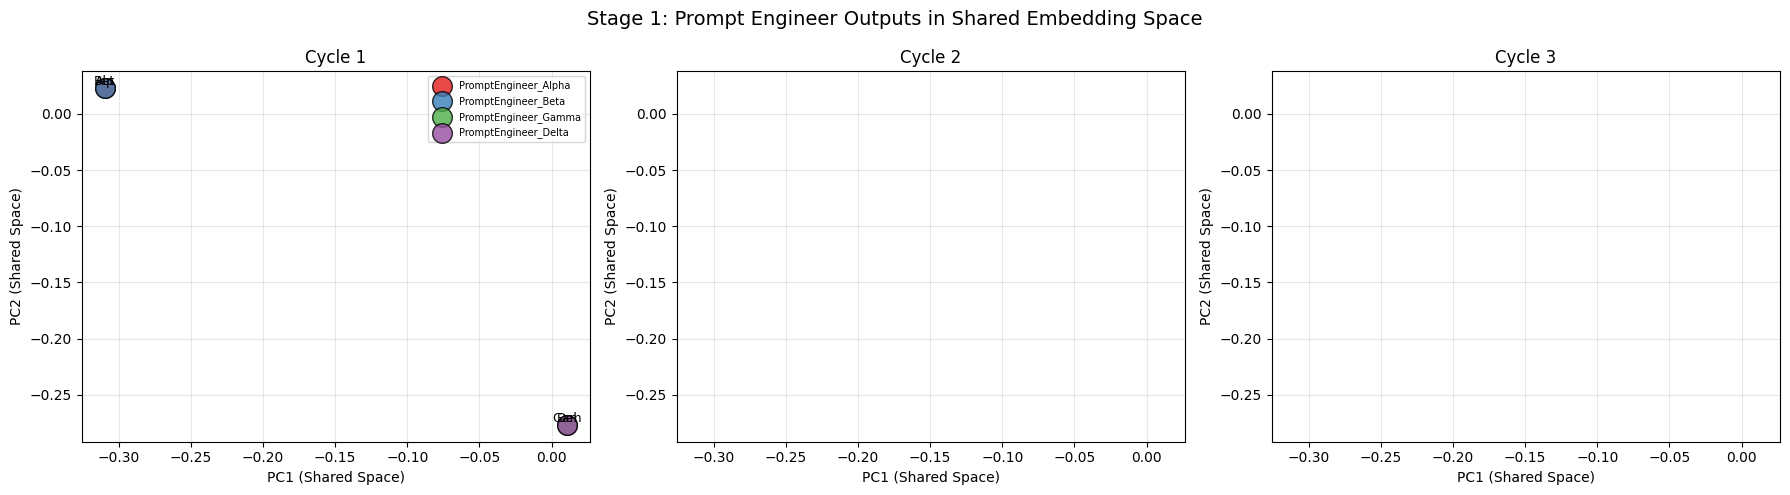


--- Stage 2 Visualization: Convergence Rounds ---


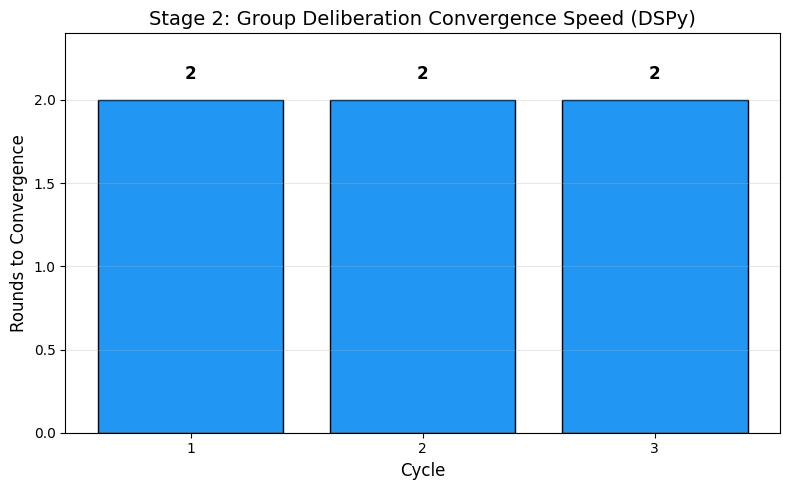


--- Stage 3 Visualization: Extraction Accuracy ---


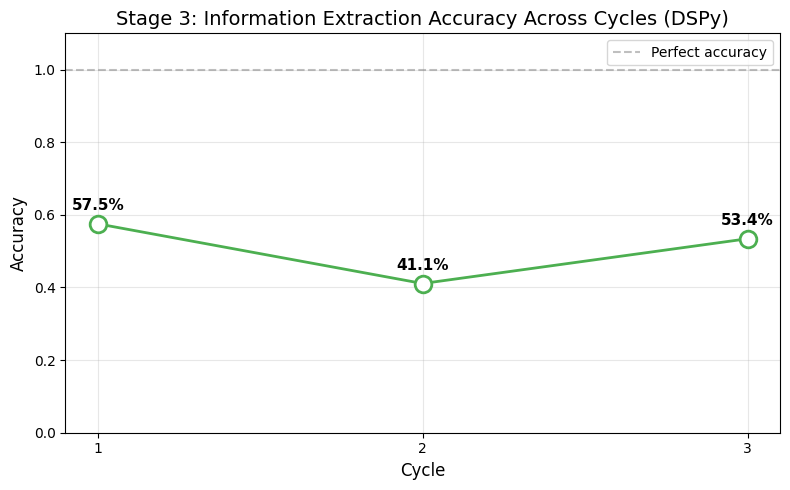

  Accuracy per cycle: ['57.53%', '41.10%', '53.42%']

ACCURACY PROGRESSION TABLE
 Cycle Accuracy  Convergence_Rounds  Prompt_Length
     1   57.53%                   2            302
     2   41.10%                   2            161
     3   53.42%                   2            590

Cycle-to-Cycle Improvements:
  Cycle 1 → 2: -16.44%
  Cycle 2 → 3: +12.33%

Total Improvement: -4.11%

QUALITATIVE ANALYSIS: FINAL PROMPTS PER CYCLE

CYCLE 1 - FINAL AGREED PROMPT
Accuracy: 57.53%
Convergence: 2 rounds
Final prompt: Extract all motifs related to the actor "Trump" from the provided content. A motif is defined as a dictionary containing the actor and their action, formatted as {actor: 'Trump', action: 'verb'}. Please return a list of these dictionaries. If there are no motifs, return an empty list [].


CYCLE 2 - FINAL AGREED PROMPT
Accuracy: 41.10%
Convergence: 2 rounds
1. **Clarity and Specificity**: The prompt should explicitly mention the need to consider various verb forms and contexts

In [25]:
# Check if sample data is loaded
if sample is None and not paper_examples:
    print("ERROR: No data loaded!")
    print("Please load your data into the 'sample' DataFrame or add 'paper_examples' before running.")
    print("Expected columns: 'posts_id', 'content', 'motifs'")
    

# Check API key
if not config.api_key:
    print("ERROR: OpenAI API key not set!")
    print("Set it via: config.api_key = 'your-key-here'")
    print("Or via environment variable: OPENAI_API_KEY")
    

# Merge paper examples with sample data
working_sample = merge_paper_examples(sample, paper_examples)

print(f"\nPipeline Configuration:")
print(f"  Sample size: {len(working_sample)} rows")
print(f"  Number of cycles: {config.num_cycles}")
print(f"  Model: {config.model}")
print(f"  Framework: DSPy")

# Run the full pipeline
results = run_full_pipeline_dspy(working_sample)

# Generate evaluation report with qualitative analysis
generate_full_evaluation_report(results, working_sample)

print(results)

# 3. Pure DSPy

Finally, let's see whether we can implement automatic prompt optimization using DSPy's built-in optimizers instead of multi-agent deliberation. Where the multi-agent setting used costly deliberative processes to find ultimately brittle prompts, DSPy modules allow for automatic prompt search using the BootstraphFewShot optimizer. Still, the approach technically requires more training data to achieve training and validation splits. And while the execution should be faster and more robust than the multi-agent deliberation, the packaged implementation makes for a slightly less interpretable process.

## Installation and Imports

In [64]:
!pip install -q dspy-ai pandas numpy matplotlib scikit-learn sentence-transformers

import os
import json
import re
import ast
from typing import List, Dict, Any, Optional, Tuple
from dataclasses import dataclass
from collections import defaultdict
from getpass import getpass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

import dspy
from dspy.teleprompt import BootstrapFewShot, BootstrapFewShotWithRandomSearch
from dspy.evaluate import Evaluate


## DSPy Configuration

In [65]:
# Configuration
@dataclass
class Config:
    """Configuration for Pure DSPy optimization."""
    # OpenAI API configuration
    api_key: str = ""
    model: str = "gpt-4o-mini"
    
    # Optimization settings
    max_bootstrapped_demos: int = 4  # Max few-shot examples to use
    max_labeled_demos: int = 4  # Max labeled examples for teaching
    num_candidates: int = 8  # Number of candidate prompts to try
    
    # Data split (for small datasets, use larger validation split)
    validation_split: float = 0.35  # 35% for validation
    random_seed: int = 42
    
    # Temperature
    temperature: float = 0.3  # Lower for consistency
    
    # Embedding model
    embedding_model: str = "all-MiniLM-L6-v2"


# Initialize config
config = Config()

# DSPy will be configured later in setup_dspy() function after API key is provided

def setup_dspy():
    """Configure DSPy with API key. Call this before running main()."""
    global config
    
    # Get API key from environment or prompt user
    if not config.api_key:
        config.api_key = os.environ.get("OPENAI_API_KEY", "")
    
    if not config.api_key:
        print("\n" + "="*70)
        print("OpenAI API Key Required")
        print("="*70)
        print("Please enter your OpenAI API key.")
        print("(Your input will be hidden for security)")
        config.api_key = getpass("OpenAI API Key: ")
    
    if not config.api_key:
        raise ValueError("API key is required to run DSPy optimization!")
    
    # Configure DSPy with the API key
    lm = dspy.LM(
        model=f"openai/{config.model}",
        api_key=config.api_key,
        temperature=config.temperature
    )
    dspy.settings.configure(lm=lm)
    
    print("\n✓ Pure DSPy configured with OpenAI")
    print(f"  Model: {config.model}")
    print(f"  Optimization: BootstrapFewShot")
    return True

## Data Loading

In [66]:
!gdown --fuzzy "https://drive.google.com/file/d/1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H/view?usp=sharing" -O /content/original_content_en_1mio.csv

path = "/content/original_content_en_1mio.csv"
messages = pd.read_csv(path)
print(f"Loaded {len(messages)} Telegram messages")

# Extract handcoded test samples
sample_ids = [8142176, 7130377, 18556553, 35168422, 33729614, 7599732, 36858681, 7221875, 36023073, 36890846, 35692943]
sample = messages[messages['posts_id'].isin(sample_ids)].copy()

Downloading...
From (original): https://drive.google.com/uc?id=1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H
From (redirected): https://drive.google.com/uc?id=1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H&confirm=t&uuid=5a580773-ff81-4b40-b553-86c09472dc4e
To: /content/original_content_en_1mio.csv
100% 364M/364M [00:04<00:00, 90.0MB/s] 
Loaded 1000000 Telegram messages


In [67]:
# Add motifs 
# Handcoded motifs for the test messages
# Format: list of dicts with "actor" and "action" keys
motifs = [
    [],  # Message 0
    [],  # Message 1
    [],  # Message 2
    [    # Message 3 (ID: 35168422)
        {"actor": "Trump", "action": "confirm"},
        {"actor": "Trump", "action": "release"},
        {"actor": "Trump", "action": "post"},
        {"actor": "Trump", "action": "promise"}
    ],
    [],  # Message 4
    [],  # Message 5
    [    # Message 6 (ID: 36858681)
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "say"},
        {"actor": "Trump", "action": "sign"}
    ],
    [    # Message 7 (ID: 7221875)
        {"actor": "Trump", "action": "have"},
        {"actor": "Trump", "action": "post"}
    ],
    [    # Message 8 (ID: 36023073)
        {"actor": "Trump", "action": "do"},
        {"actor": "Trump", "action": "help"},
        {"actor": "Trump", "action": "give away"}
    ],
    [    # Message 9 (ID: 36890846)
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "sign"},
        {"actor": "Trump", "action": "say"},
        {"actor": "Trump", "action": "say"}
    ],
    [    # Message 10 (ID: 35692943)
        {"actor": "Trump", "action": "go"},
        {"actor": "Trump", "action": "come back"},
        {"actor": "Trump", "action": "talk"}
    ]
]

# Add handcoded labels to test_messages dataframe
sample['motifs'] = motifs

print(f"Loaded handcoded labels for {len(sample)} messages")
print(f"Messages with non-empty labels: {sum(1 for m in motifs if len(m) > 0)}")
print(f"Total handcoded motifs: {sum(len(m) for m in motifs)}")

Loaded handcoded labels for 11 messages
Messages with non-empty labels: 6
Total handcoded motifs: 20


In [68]:
paper_examples = [
    # Original paper examples
    ("Trump calls.", [{"actor": "Trump", "action": "call"}]),
    ("Trump can call.", [{"actor": "Trump", "action": "can"}, {"actor": "Trump", "action": "call"}]),
    ("Trump rings and asks.", [{"actor": "Trump", "action": "ring"}, {"actor": "Trump", "action": "ask"}]),
    ("Biden and Trump talked.", [{"actor": "Trump", "action": "talk"}]),
    ("Biden was received by Trump.", [{"actor": "Trump", "action": "receive"}]),
    ("My friend Trump spotted Biden.", [{"actor": "Trump", "action": "spot"}]),
    ("Trump wants to eat.", [{"actor": "Trump", "action": "want"}, {"actor": "Trump", "action": "eat"}]),
    ("Trump wants you to visit.", [{"actor": "Trump", "action": "want"}]),

    # Additional 30 synthetic examples with motif annotations
    ("Though unconfirmed, it was rumored that Trump had contacted the agency before the decision was announced.", [
        {"actor": "Trump", "action": "contact"},
        {"actor": "Trump", "action": "have contacted"}
    ]),
    ("Having been advised by multiple aides, Trump eventually authorized the operation after lengthy deliberations.", [
        {"actor": "Trump", "action": "be advised"},
        {"actor": "Trump", "action": "authorize"},
        {"actor": "Trump", "action": "deliberate"}
    ]),
    ("If the evidence presented by Trump’s legal team were verified, the proceedings could restart.", [
        {"actor": "Trump", "action": "present"}
    ]),
    ("Not only did Trump postpone the meeting, but he also delegated key tasks to his chief strategist.", [
        {"actor": "Trump", "action": "postpone"},
        {"actor": "Trump", "action": "delegate"}
    ]),
    ("Prior to arriving in the city, Trump, who had consulted several experts, issued a formal statement regarding the ongoing negotiations.", [
        {"actor": "Trump", "action": "arrive"},
        {"actor": "Trump", "action": "consult"},
        {"actor": "Trump", "action": "issue"}
    ]),
    ("Trump was never officially informed about the protest, according to a source familiar with the matter.", [
        {"actor": "Trump", "action": "be informed"}
    ]),
    ("No sooner had Trump concluded the conference than he began drafting his response to critics.", [
        {"actor": "Trump", "action": "conclude"},
        {"actor": "Trump", "action": "draft"}
    ]),
    ("Although the bill was written by Congress, it was Trump who insisted it be revised before being signed.", [
        {"actor": "Trump", "action": "insist"},
        {"actor": "Trump", "action": "be signed"}
    ]),
    ("By the time the journalists arrived, Trump was already answering questions on the live broadcast.", [
        {"actor": "Trump", "action": "answer"}
    ]),
    ("Many assumed Trump would have attended the gala, had his schedule permitted.", [
        {"actor": "Trump", "action": "attend"}
    ]),
    ("Despite his earlier reluctance, Trump ended up promoting the new policy in several media appearances.", [
        {"actor": "Trump", "action": "promote"}
    ]),
    ("The document, supposedly prepared by Trump himself, remained unverified.", [
        {"actor": "Trump", "action": "prepare"}
    ]),
    ("Had Trump not intervened, the negotiations might have collapsed altogether.", [
        {"actor": "Trump", "action": "intervene"}
    ]),
    ("Once the announcement was made, Trump’s team organized a press briefing to clarify the details.", [
        {"actor": "Trump", "action": "organize"}
    ]),
    ("Trump was alleged to have influenced the votes through indirect channels.", [
        {"actor": "Trump", "action": "have influenced"}
    ]),
    ("Even though Trump denied knowing the details, investigators later found evidence to the contrary.", [
        {"actor": "Trump", "action": "deny"},
        {"actor": "Trump", "action": "know"}
    ]),
    ("Only after his advisors had reviewed the proposal did Trump give his approval, emphasizing transparency.", [
        {"actor": "Trump", "action": "approve"},
        {"actor": "Trump", "action": "emphasize"}
    ]),
    ("If Trump had not signed the bill, the funding would have been delayed.", [
        {"actor": "Trump", "action": "sign"}
    ]),
    ("It was speculated that Trump might have reconsidered, had he been offered more information.", [
        {"actor": "Trump", "action": "reconsider"}
    ]),
    ("After learning Trump would visit the site, local officials rushed to prepare.", [
        {"actor": "Trump", "action": "visit"}
    ]),
    ("Trump, despite being heavily criticized, persisted in implementing the controversial reforms.", [
        {"actor": "Trump", "action": "persist"},
        {"actor": "Trump", "action": "implement"}
    ]),
    ("The reforms, which Trump had promised for months, were finally set in motion.", [
        {"actor": "Trump", "action": "promise"}
    ]),
    ("Though offered several options, Trump chose to delay the vote until further notice.", [
        {"actor": "Trump", "action": "choose"},
        {"actor": "Trump", "action": "delay"}
    ]),
    ("The press conference, hosted by Trump and his advisors, was broadcast worldwide.", [
        {"actor": "Trump", "action": "host"}
    ]),
    ("Under mounting pressure, Trump was said to have authorized an internal review.", [
        {"actor": "Trump", "action": "authorize"}
    ]),
    ("Despite their concerns, Trump encouraged the committee to proceed with the plan.", [
        {"actor": "Trump", "action": "encourage"}
    ]),
    ("Having been delayed by unforeseen events, Trump finally started the second round of talks after midnight.", [
        {"actor": "Trump", "action": "start"}
    ]),
    ("He might not have agreed with the outcome, but Trump still officially endorsed the report.", [
        {"actor": "Trump", "action": "endorse"}
    ]),
    ("Trump, whose earlier remarks had surprised the panel, remained silent during follow-up questions.", [
        {"actor": "Trump", "action": "remark"},
        {"actor": "Trump", "action": "remain silent"}
    ]),
    ("If Trump had been informed sooner, he might have proposed alternative solutions.", [
        {"actor": "Trump", "action": "propose"}
    ]),
    ("After months of speculation, the policy was announced by Trump in a brief televised address.", [
        {"actor": "Trump", "action": "announce"}
    ]),
    ("Even when confronted by detractors, Trump maintained his position and reiterated his commitment.", [
        {"actor": "Trump", "action": "maintain"},
        {"actor": "Trump", "action": "reiterate"}
    ])
]


def prepare_dataset(sample_df: pd.DataFrame, paper_examples: List[Tuple[str, List[Dict[str, str]]]]) -> pd.DataFrame:
    """Prepare and merge all data sources."""
    
    # Convert paper examples to DataFrame
    if paper_examples:
        paper_df = pd.DataFrame(paper_examples, columns=['content', 'motifs'])
        start_id = sample_df['posts_id'].max() + 1 if sample_df is not None else 1000
        paper_df['posts_id'] = range(start_id, start_id + len(paper_df))
        paper_df = paper_df[['posts_id', 'content', 'motifs']]
        
        if sample_df is not None:
            combined = pd.concat([sample_df, paper_df], ignore_index=True)
            print(f"✓ Merged {len(paper_df)} paper examples with {len(sample_df)} original samples")
        else:
            combined = paper_df
            print(f"✓ Using {len(paper_df)} paper examples")
    else:
        combined = sample_df
    
    print(f"  Total dataset size: {len(combined)}")
    return combined

## DSPy Classes and Modules

In [84]:
# Example class
class MotifExample(dspy.Example):
    """DSPy Example class for motif extraction task."""
    
    def __init__(self, content: str = None, motifs: List[Dict[str, str]] = None, posts_id: int = None, base=None, **kwargs):
        # If base is provided, we're copying from another example
        if base is not None:
            super().__init__(base=base, **kwargs)
        else:
            super().__init__(
                content=content,
                motifs=motifs,
                posts_id=posts_id
            )
        # Note: with_inputs() should be called after instantiation, not in __init__


def create_dspy_examples(df: pd.DataFrame) -> List[MotifExample]:
    """Convert DataFrame to DSPy Examples."""
    examples = []
    for _, row in df.iterrows():
        example = MotifExample(
            content=row['content'],
            motifs=row['motifs'],
            posts_id=row['posts_id']
        )
        # Mark content as input field (motifs and posts_id are outputs/metadata)
        example = example.with_inputs("content")
        examples.append(example)
    return examples


# ============================================================================
# DSPY MODULE FOR MOTIF EXTRACTION
# ============================================================================

class MotifExtractionSignature(dspy.Signature):
    """Extract Trump-related motifs from social media text."""
    
    content = dspy.InputField(
        desc="Social media post text to analyze for Trump-related motifs"
    )
    motifs = dspy.OutputField(
        desc="List of Trump-related motifs as Python list of dictionaries with 'actor' and 'action' keys. "
             "Example: [{'actor': 'Trump', 'action': 'sign'}, {'actor': 'Trump', 'action': 'say'}]. "
             "Return [] (empty list) if no Trump-related motifs are found."
    )


class MotifExtractorModule(dspy.Module):
    """DSPy module for extracting motifs from text."""
    
    def __init__(self):
        super().__init__()
        # Use ChainOfThought for better reasoning
        self.predictor = dspy.ChainOfThought(MotifExtractionSignature)
    
    def forward(self, content: str) -> dspy.Prediction:
        """Extract motifs from content."""
        return self.predictor(content=content)


# ============================================================================
# METRIC FUNCTION
# ============================================================================

def motif_accuracy_metric(example: MotifExample, prediction: dspy.Prediction, trace=None) -> float:
    """
    Calculate accuracy for a single example with structured motifs.
    Returns 1.0 for perfect match, proportional score for partial match.
    """
    try:
        # Parse prediction
        pred_str = prediction.motifs
        
        # Try to extract list
        list_match = re.search(r'\[.*?\]', pred_str, re.DOTALL)
        if list_match:
            pred_motifs = ast.literal_eval(list_match.group())
        else:
            pred_motifs = []
        
        # Convert lists of dicts to sets of tuples for comparison
        pred_set = set()
        if isinstance(pred_motifs, list):
            for item in pred_motifs:
                if isinstance(item, dict) and 'actor' in item and 'action' in item:
                    pred_set.add((item['actor'], item['action']))
        
        truth_set = set()
        if isinstance(example.motifs, list):
            for item in example.motifs:
                if isinstance(item, dict) and 'actor' in item and 'action' in item:
                    truth_set.add((item['actor'], item['action']))
        
        # Calculate F1-like score
        if len(truth_set) == 0:
            return 1.0 if len(pred_set) == 0 else 0.0
        
        # Intersection over union (Jaccard similarity)
        intersection = len(pred_set & truth_set)
        union = len(pred_set | truth_set)
        
        return intersection / union if union > 0 else 0.0
        
    except Exception as e:
        print(f"  Warning in metric calculation: {e}")
        return 0.0


def batch_accuracy_metric(examples: List[MotifExample], predictions: List[dspy.Prediction]) -> float:
    """Calculate average accuracy across multiple examples."""
    scores = []
    for ex, pred in zip(examples, predictions):
        score = motif_accuracy_metric(ex, pred)
        scores.append(score)
    return sum(scores) / len(scores) if scores else 0.0


# ============================================================================
# OPTIMIZATION PROCESS
# ============================================================================

def run_optimization(trainset: List[MotifExample], valset: List[MotifExample]) -> Tuple[MotifExtractorModule, Dict[str, Any]]:
    """
    Run DSPy optimization to find the best prompt.
    
    Returns optimized module and metrics.
    """
    print("\n" + "="*70)
    print("RUNNING PURE DSPY OPTIMIZATION")
    print("="*70)
    
    print(f"\nDataset split:")
    print(f"  Training set: {len(trainset)} examples")
    print(f"  Validation set: {len(valset)} examples")
    
    # Create unoptimized baseline module
    baseline_module = MotifExtractorModule()
    
    # Evaluate baseline
    print("\n--- Evaluating Baseline (Unoptimized) ---")
    evaluator = Evaluate(
        devset=valset,
        metric=motif_accuracy_metric,
        num_threads=1,
        display_progress=True,
        display_table=0  # Don't print table for each example
    )
    
    baseline_score = evaluator(baseline_module)
    # Extract the actual score value from EvaluationResult
    # Note: EvaluationResult already returns percentage (0-100), so divide by 100 for proper formatting
    baseline_score_value = float(baseline_score) / 100 if hasattr(baseline_score, '__float__') else baseline_score
    print(f"  Baseline accuracy on validation set: {baseline_score_value:.2%}")
    
    # Run optimization
    print("\n--- Running BootstrapFewShot Optimization ---")
    print(f"  Max bootstrapped demos: {config.max_bootstrapped_demos}")
    print(f"  Max labeled demos: {config.max_labeled_demos}")
    print(f"  Candidates to try: {config.num_candidates}")
    print("\n  This may take several minutes...")
    
    optimizer = BootstrapFewShot(
        metric=motif_accuracy_metric,
        max_bootstrapped_demos=config.max_bootstrapped_demos,
        max_labeled_demos=config.max_labeled_demos,
        max_rounds=1,  # One round of bootstrapping
    )
    
    # Compile (optimize) the module
    optimized_module = optimizer.compile(
        baseline_module,
        trainset=trainset
    )
    
    # Evaluate optimized module
    print("\n--- Evaluating Optimized Module ---")
    optimized_score = evaluator(optimized_module)
    # Extract the actual score value from EvaluationResult
    # Note: EvaluationResult already returns percentage (0-100), so divide by 100 for proper formatting
    optimized_score_value = float(optimized_score) / 100 if hasattr(optimized_score, '__float__') else optimized_score
    print(f"  Optimized accuracy on validation set: {optimized_score_value:.2%}")
    
    # Calculate improvement
    improvement = optimized_score_value - baseline_score_value
    print(f"\n  Improvement: {improvement:+.2%}")
    
    metrics = {
        "baseline_score": baseline_score_value,
        "optimized_score": optimized_score_value,
        "improvement": improvement,
        "trainset_size": len(trainset),
        "valset_size": len(valset)
    }
    
    return optimized_module, metrics

## Analysis Functions

In [85]:
#Analysis
def extract_prompt_from_module(module: MotifExtractorModule) -> str:
    """Extract the actual prompt being used by the module."""
    try:
        # DSPy stores prompts in the predictor's history
        # This is a simplified extraction - actual implementation may vary
        if hasattr(module.predictor, 'extended_signature'):
            sig = module.predictor.extended_signature
            return f"Signature: {sig}"
        elif hasattr(module.predictor, 'signature'):
            return f"Signature: {module.predictor.signature}"
        else:
            return "Prompt inspection not available (check DSPy version)"
    except Exception as e:
        return f"Could not extract prompt: {e}"


def analyze_few_shot_examples(module: MotifExtractorModule, trainset: List[MotifExample]):
    """Analyze which examples the optimizer selected for few-shot demonstrations."""
    print("\n" + "="*70)
    print("ANALYSIS: FEW-SHOT EXAMPLES SELECTED BY OPTIMIZER")
    print("="*70)
    
    try:
        # Try to extract demonstrations from the module
        if hasattr(module.predictor, 'demos') and module.predictor.demos:
            demos = module.predictor.demos
            print(f"\nOptimizer selected {len(demos)} few-shot demonstrations:")
            
            for i, demo in enumerate(demos):
                print(f"\n--- Demo {i+1} ---")
                content = demo.content if hasattr(demo, 'content') else str(demo)[:200]
                print(f"Content: {content[:200]}...")
                if hasattr(demo, 'motifs'):
                    print(f"Motifs: {demo.motifs}")
        else:
            print("\nNo few-shot demonstrations found (optimizer may not have added any)")
            print("This can happen with very small datasets")
    
    except Exception as e:
        print(f"\nCould not analyze few-shot examples: {e}")
        print("This is normal - DSPy's internal structure varies by version")


def qualitative_comparison(baseline_module: MotifExtractorModule, 
                          optimized_module: MotifExtractorModule,
                          valset: List[MotifExample],
                          num_samples: int = 10):
    """Compare baseline vs optimized outputs qualitatively."""
    print("\n" + "="*70)
    print("QUALITATIVE COMPARISON: BASELINE vs OPTIMIZED")
    print("="*70)
    
    num_samples = min(num_samples, len(valset))
    
    for idx in range(num_samples):
        example = valset[idx]
        
        print(f"\n{'='*70}")
        print(f"EXAMPLE {idx + 1}")
        print(f"{'='*70}")
        
        # Show content
        content = example.content
        if len(content) > 300:
            print(f"Content: {content[:300]}...")
        else:
            print(f"Content: {content}")
        
        # Convert ground truth to set of tuples for comparison
        truth_set = set()
        if isinstance(example.motifs, list):
            for m in example.motifs:
                if isinstance(m, dict):
                    truth_set.add((m.get('actor', ''), m.get('action', '')))
        
        print(f"\nGround Truth: {example.motifs}")
        
        # Baseline prediction
        baseline_correct = False
        try:
            baseline_pred = baseline_module(content=content)
            baseline_motifs = parse_motifs(baseline_pred.motifs)
            
            # Convert to set of tuples
            baseline_set = set()
            for m in baseline_motifs:
                if isinstance(m, dict):
                    baseline_set.add((m.get('actor', ''), m.get('action', '')))
            
            baseline_correct = baseline_set == truth_set
            baseline_icon = "✓" if baseline_correct else "✗"
            print(f"\nBaseline Prediction: {baseline_motifs} {baseline_icon}")
        except Exception as e:
            print(f"\nBaseline Prediction: ERROR - {e}")
        
        # Optimized prediction
        optimized_correct = False
        try:
            optimized_pred = optimized_module(content=content)
            optimized_motifs = parse_motifs(optimized_pred.motifs)
            
            # Convert to set of tuples
            optimized_set = set()
            for m in optimized_motifs:
                if isinstance(m, dict):
                    optimized_set.add((m.get('actor', ''), m.get('action', '')))
            
            optimized_correct = optimized_set == truth_set
            optimized_icon = "✓" if optimized_correct else "✗"
            print(f"Optimized Prediction: {optimized_motifs} {optimized_icon}")
        except Exception as e:
            print(f"Optimized Prediction: ERROR - {e}")
        
        # Show if there was improvement
        if not baseline_correct and optimized_correct:
            print("  → IMPROVEMENT: Optimized got it right!")
        elif baseline_correct and not optimized_correct:
            print("  → REGRESSION: Baseline was better")


def parse_motifs(motifs_str: str) -> List[Dict[str, str]]:
    """Parse motifs from string to list of dicts."""
    try:
        list_match = re.search(r'\[.*?\]', motifs_str, re.DOTALL)
        if list_match:
            parsed = ast.literal_eval(list_match.group())
            if isinstance(parsed, list):
                # Validate structure
                valid_motifs = []
                for item in parsed:
                    if isinstance(item, dict) and 'actor' in item and 'action' in item:
                        valid_motifs.append(item)
                return valid_motifs
        return []
    except:
        return []


In [86]:
# VISUALIZATION FUNCTIONS

def plot_optimization_process(metrics: Dict[str, Any]):
    """Visualize the optimization improvement."""
    print("\n--- Optimization Results ---")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left plot: Baseline vs Optimized
    methods = ['Baseline\n(Zero-shot)', 'Optimized\n(Few-shot)']
    scores = [metrics['baseline_score'], metrics['optimized_score']]
    colors = ['#FF6B6B', '#4CAF50']
    
    bars = ax1.bar(methods, scores, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
    
    # Add value labels
    for bar, score in zip(bars, scores):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{score:.1%}', ha='center', va='bottom', fontsize=14, fontweight='bold')
    
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Pure DSPy Optimization: Before vs After', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, 1.1)
    ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    ax1.grid(axis='y', alpha=0.3)
    
    # Right plot: Improvement breakdown
    improvement = metrics['improvement']
    improvement_pct = improvement * 100
    
    ax2.barh(['Improvement'], [improvement_pct], color='#2196F3', edgecolor='black', linewidth=2)
    ax2.axvline(x=0, color='black', linewidth=1)
    ax2.set_xlabel('Percentage Point Improvement', fontsize=12)
    ax2.set_title('Absolute Improvement', fontsize=14, fontweight='bold')
    ax2.text(improvement_pct/2, 0, f'{improvement:+.1%}', 
            ha='center', va='center', fontsize=16, fontweight='bold', color='white')
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_dataset_split(trainset: List[MotifExample], valset: List[MotifExample]):
    """Visualize the train/validation split."""
    print("\n--- Dataset Split Visualization ---")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Count motifs in each set
    train_motif_counts = defaultdict(int)
    val_motif_counts = defaultdict(int)
    
    for ex in trainset:
        for motif in ex.motifs:
            # Convert dict to tuple for hashability
            if isinstance(motif, dict):
                motif_key = (motif.get('actor', ''), motif.get('action', ''))
            else:
                motif_key = motif
            train_motif_counts[motif_key] += 1
    
    for ex in valset:
        for motif in ex.motifs:
            # Convert dict to tuple for hashability
            if isinstance(motif, dict):
                motif_key = (motif.get('actor', ''), motif.get('action', ''))
            else:
                motif_key = motif
            val_motif_counts[motif_key] += 1
    
    # Get all unique motifs
    all_motifs = sorted(set(list(train_motif_counts.keys()) + list(val_motif_counts.keys())))
    
    # Prepare data for grouped bar chart
    x = np.arange(len(all_motifs))
    width = 0.35
    
    train_counts = [train_motif_counts[m] for m in all_motifs]
    val_counts = [val_motif_counts[m] for m in all_motifs]
    
    ax.bar(x - width/2, train_counts, width, label='Training Set', color='#2196F3', edgecolor='black')
    ax.bar(x + width/2, val_counts, width, label='Validation Set', color='#FF9800', edgecolor='black')
    
    ax.set_xlabel('Motif Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Motif Distribution Across Train/Val Split\n(Train: {len(trainset)}, Val: {len(valset)})', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    # Format tuples as "actor: action" for readability
    motif_labels = [f"{m[0]}: {m[1]}" if isinstance(m, tuple) else str(m) for m in all_motifs]
    ax.set_xticklabels(motif_labels, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_error_analysis(module: MotifExtractorModule, valset: List[MotifExample], title: str):
    """Analyze and visualize errors made by the module."""
    print(f"\n--- Error Analysis: {title} ---")
    
    errors = {
        'false_positives': 0,  # Predicted motifs that aren't in ground truth
        'false_negatives': 0,  # Missed motifs that are in ground truth
        'perfect_matches': 0,   # Completely correct
        'parse_errors': 0       # Failed to parse output
    }
    
    for example in valset:
        try:
            pred = module(content=example.content)
            pred_motifs = parse_motifs(pred.motifs)
            
            # Convert to sets of tuples for comparison
            pred_set = set()
            for m in pred_motifs:
                if isinstance(m, dict):
                    pred_set.add((m.get('actor', ''), m.get('action', '')))
            
            truth_set = set()
            if isinstance(example.motifs, list):
                for m in example.motifs:
                    if isinstance(m, dict):
                        truth_set.add((m.get('actor', ''), m.get('action', '')))
            
            if pred_set == truth_set:
                errors['perfect_matches'] += 1
            else:
                fps = len(pred_set - truth_set)
                fns = len(truth_set - pred_set)
                errors['false_positives'] += fps
                errors['false_negatives'] += fns
        
        except Exception as e:
            errors['parse_errors'] += 1
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    categories = list(errors.keys())
    values = list(errors.values())
    colors = ['#4CAF50', '#FF6B6B', '#FFA726', '#9C27B0']
    
    bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5)
    
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                   str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Error Analysis: {title}', fontsize=14, fontweight='bold')
    ax.set_xticklabels(categories, rotation=30, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print error summary
    total_errors = errors['false_positives'] + errors['false_negatives']
    print(f"\nError Summary:")
    print(f"  Perfect matches: {errors['perfect_matches']}/{len(valset)}")
    print(f"  False positives: {errors['false_positives']}")
    print(f"  False negatives: {errors['false_negatives']}")
    print(f"  Parse errors: {errors['parse_errors']}")


def visualize_prompt_evolution(baseline_module: MotifExtractorModule, 
                               optimized_module: MotifExtractorModule):
    """Visualize how the prompt changed through optimization."""
    print("\n--- Prompt Evolution Analysis ---")
    
    # Try to extract prompts (DSPy's internal representation)
    print("\nAttempting to inspect prompt changes...")
    print("(Note: DSPy may not expose full prompt text depending on version)")
    
    try:
        # Inspect baseline
        print("\n=== BASELINE MODULE ===")
        print(f"Type: {type(baseline_module.predictor).__name__}")
        
        # Inspect optimized  
        print("\n=== OPTIMIZED MODULE ===")
        print(f"Type: {type(optimized_module.predictor).__name__}")
        
        # Check for demonstrations
        if hasattr(optimized_module.predictor, 'demos'):
            print(f"Few-shot demos added: {len(optimized_module.predictor.demos)}")
        
        # Visualize with embeddings if possible
        model = SentenceTransformer(config.embedding_model)
        
        # Get some representation of the prompts
        baseline_repr = str(baseline_module.predictor.signature)
        optimized_repr = str(optimized_module.predictor.signature)
        
        if hasattr(optimized_module.predictor, 'demos') and optimized_module.predictor.demos:
            # Add demo content to representation
            demo_texts = [str(d)[:200] for d in optimized_module.predictor.demos]
            optimized_repr += " " + " ".join(demo_texts)
        
        embeddings = model.encode([baseline_repr, optimized_repr])
        
        # Simple comparison
        similarity = np.dot(embeddings[0], embeddings[1]) / (
            np.linalg.norm(embeddings[0]) * np.linalg.norm(embeddings[1])
        )
        
        print(f"\nPrompt similarity (cosine): {similarity:.3f}")
        if similarity > 0.95:
            print("  → Prompts are very similar (minor changes)")
        elif similarity > 0.8:
            print("  → Prompts are moderately similar (some changes)")
        else:
            print("  → Prompts are quite different (significant changes)")
    
    except Exception as e:
        print(f"\nPrompt inspection not fully available: {e}")
        print("This is expected - DSPy abstracts away prompt details")


def print_optimization_summary(metrics: Dict[str, Any], trainset: List[MotifExample], valset: List[MotifExample]):
    """Print comprehensive summary of optimization."""
    print("\n" + "="*70)
    print("OPTIMIZATION SUMMARY")
    print("="*70)
    
    print(f"\n📊 Dataset Information:")
    print(f"  Total examples: {len(trainset) + len(valset)}")
    print(f"  Training set: {len(trainset)} ({len(trainset)/(len(trainset)+len(valset))*100:.0f}%)")
    print(f"  Validation set: {len(valset)} ({len(valset)/(len(trainset)+len(valset))*100:.0f}%)")
    
    print(f"\n🎯 Performance:")
    print(f"  Baseline (unoptimized): {metrics['baseline_score']:.2%}")
    print(f"  Optimized (few-shot):   {metrics['optimized_score']:.2%}")
    print(f"  Improvement:            {metrics['improvement']:+.2%}")
    
    improvement_pct = (metrics['improvement'] / metrics['baseline_score'] * 100) if metrics['baseline_score'] > 0 else 0
    print(f"  Relative improvement:   {improvement_pct:+.1f}%")
    
    print(f"\n⚙️  Optimizer Settings:")
    print(f"  Max bootstrapped demos: {config.max_bootstrapped_demos}")
    print(f"  Max labeled demos:      {config.max_labeled_demos}")
    print(f"  Model:                  {config.model}")
    print(f"  Temperature:            {config.temperature}")

## Main Execution Flow

SETUP: Configuring DSPy

✓ Pure DSPy configured with OpenAI
  Model: gpt-4o-mini
  Optimization: BootstrapFewShot
✓ Merged 40 paper examples with 11 original samples
  Total dataset size: 51

--- Converting to DSPy Examples ---
  Created 51 DSPy examples

--- Splitting Data ---
  Training: 33 examples
  Validation: 18 examples

--- Dataset Split Visualization ---


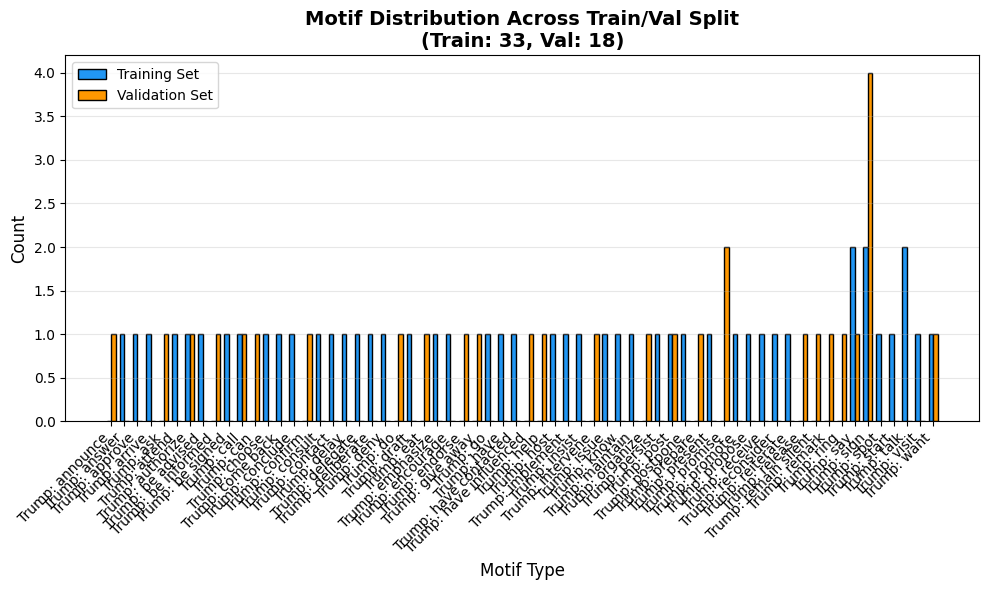


RUNNING PURE DSPY OPTIMIZATION

Dataset split:
  Training set: 33 examples
  Validation set: 18 examples

--- Evaluating Baseline (Unoptimized) ---
Average Metric: 9.10 / 18 (50.6%): 100%|██████████| 18/18 [00:00<00:00, 73.98it/s]

2026/02/06 03:26:22 INFO dspy.evaluate.evaluate: Average Metric: 9.1 / 18 (50.6%)



  Baseline accuracy on validation set: 50.56%

--- Running BootstrapFewShot Optimization ---
  Max bootstrapped demos: 4
  Max labeled demos: 4
  Candidates to try: 8

  This may take several minutes...


 12%|█▏        | 4/33 [00:00<00:03,  9.06it/s]


Bootstrapped 4 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.

--- Evaluating Optimized Module ---
Average Metric: 11.33 / 18 (63.0%): 100%|██████████| 18/18 [00:00<00:00, 80.55it/s]

2026/02/06 03:26:23 INFO dspy.evaluate.evaluate: Average Metric: 11.333333333333334 / 18 (63.0%)



  Optimized accuracy on validation set: 62.96%

  Improvement: +12.40%

--- Optimization Results ---


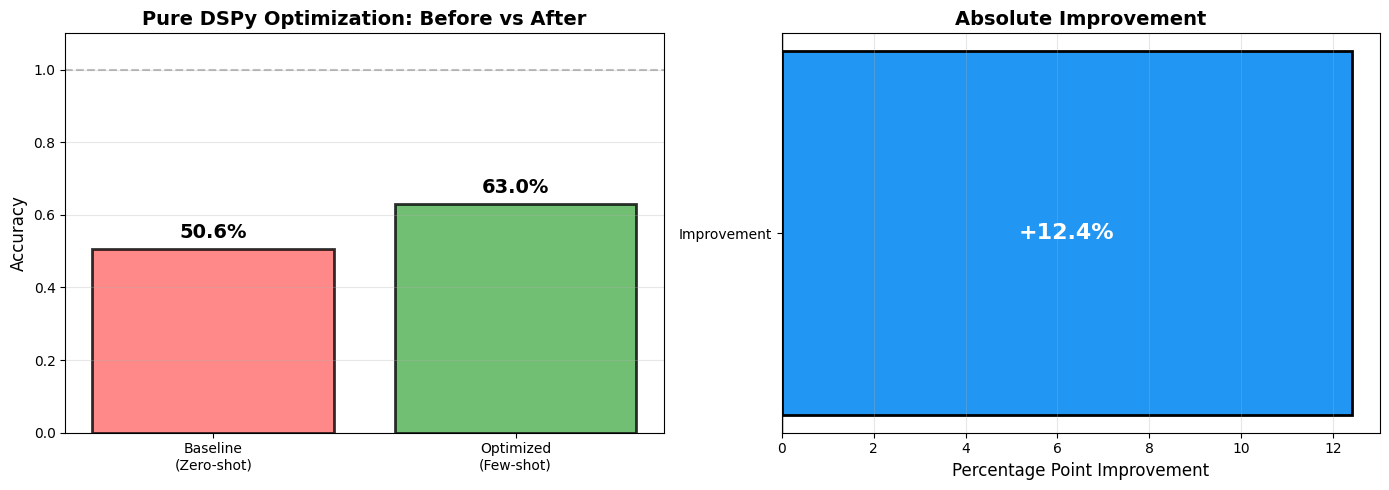


--- Error Analysis: Baseline (Unoptimized) ---


/tmp/ipython-input-576875506.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=30, ha='right')


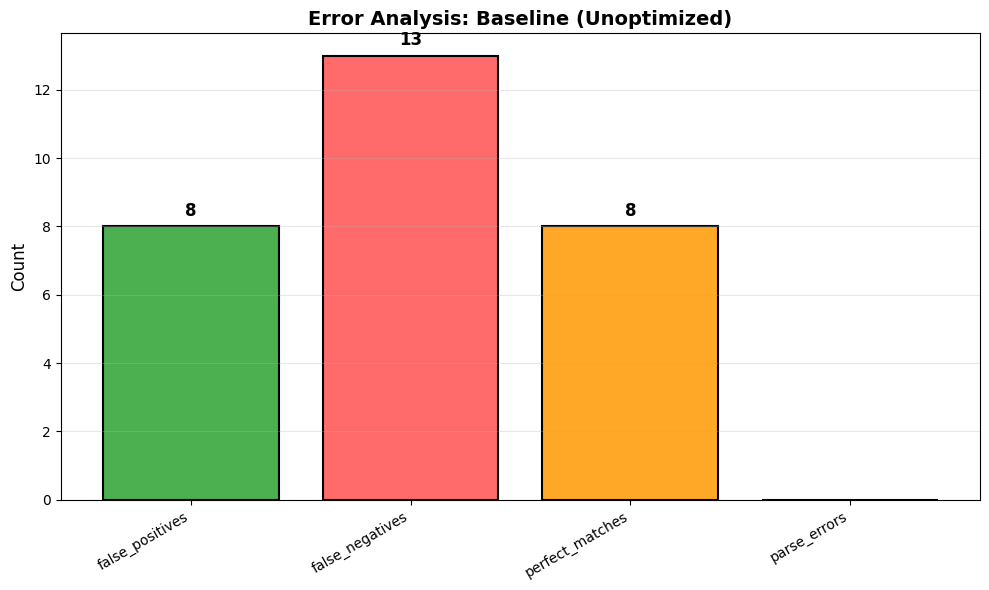


Error Summary:
  Perfect matches: 8/18
  False positives: 8
  False negatives: 13
  Parse errors: 0

--- Error Analysis: Optimized ---


/tmp/ipython-input-576875506.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=30, ha='right')


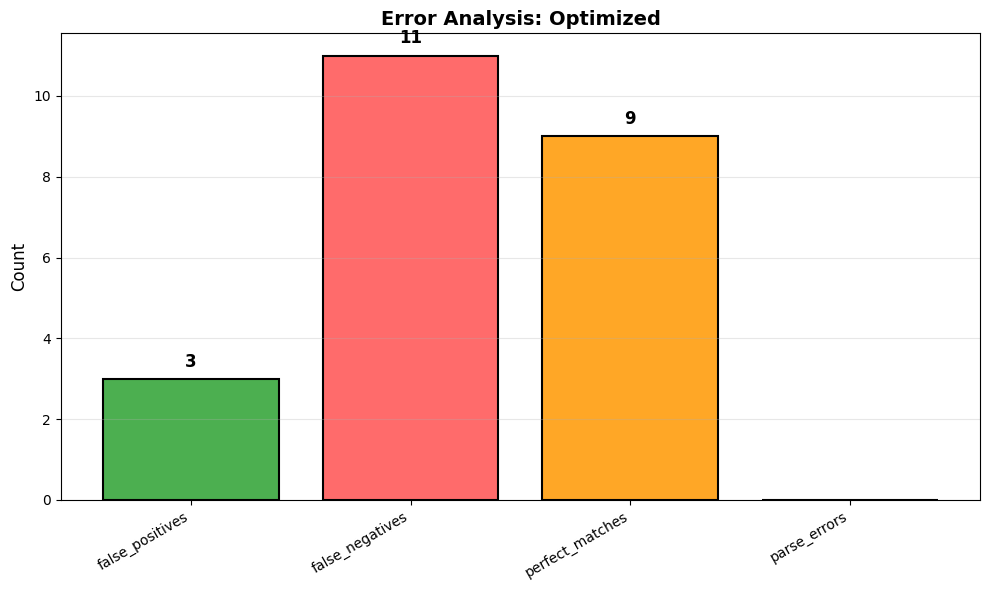


Error Summary:
  Perfect matches: 9/18
  False positives: 3
  False negatives: 11
  Parse errors: 0

ANALYSIS: FEW-SHOT EXAMPLES SELECTED BY OPTIMIZER

No few-shot demonstrations found (optimizer may not have added any)
This can happen with very small datasets

--- Prompt Evolution Analysis ---

Attempting to inspect prompt changes...
(Note: DSPy may not expose full prompt text depending on version)

=== BASELINE MODULE ===
Type: ChainOfThought

=== OPTIMIZED MODULE ===
Type: ChainOfThought


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Prompt inspection not fully available: 'ChainOfThought' object has no attribute 'signature'
This is expected - DSPy abstracts away prompt details

QUALITATIVE COMPARISON: BASELINE vs OPTIMIZED

EXAMPLE 1
Content: Under mounting pressure, Trump was said to have authorized an internal review.

Ground Truth: [{'actor': 'Trump', 'action': 'authorize'}]

Baseline Prediction: [{'actor': 'Trump', 'action': 'authorize'}] ✓
Optimized Prediction: [{'actor': 'Trump', 'action': 'authorize'}] ✓

EXAMPLE 2
Content: The reforms, which Trump had promised for months, were finally set in motion.

Ground Truth: [{'actor': 'Trump', 'action': 'promise'}]

Baseline Prediction: [{'actor': 'Trump', 'action': 'promise'}, {'actor': 'Trump', 'action': 'set in motion'}] ✗
Optimized Prediction: [{'actor': 'Trump', 'action': 'promise'}] ✓
  → IMPROVEMENT: Optimized got it right!

EXAMPLE 3
Content: He might not have agreed with the outcome, but Trump still officially endorsed the report.

Ground Truth: [{'actor': 

In [87]:
# MAIN EXECUTION FLOW
# Setup DSPy with API key
print("SETUP: Configuring DSPy")

try:
    setup_dspy()
except ValueError as e:
    print(f"\nERROR: {e}")

# Check data
if sample is None and not paper_examples:
    print("\nERROR: No data loaded!")
    print("Please load 'sample' DataFrame or add 'paper_examples'")

# Prepare dataset
full_dataset = prepare_dataset(sample, paper_examples)

# Check minimum size
if len(full_dataset) < 10:
    print("\n⚠️  WARNING: Dataset is very small (< 10 examples)")
    print("Pure DSPy optimization works best with 30+ examples")
    print("Consider using the hybrid approach instead (w5_pilot_dspy.py)")
    print("\nContinuing anyway for demonstration purposes...")

# Create DSPy examples
print("\n--- Converting to DSPy Examples ---")
examples = create_dspy_examples(full_dataset)
print(f"  Created {len(examples)} DSPy examples")

# Split into train/validation
print("\n--- Splitting Data ---")
trainset, valset = train_test_split(
    examples,
    test_size=config.validation_split,
    random_state=config.random_seed
)

print(f"  Training: {len(trainset)} examples")
print(f"  Validation: {len(valset)} examples")

# Visualize split
plot_dataset_split(trainset, valset)

# Create baseline module (for comparison)
baseline_module = MotifExtractorModule()

# Run optimization
optimized_module, metrics = run_optimization(trainset, valset)

# Visualizations
plot_optimization_process(metrics)
plot_error_analysis(baseline_module, valset, "Baseline (Unoptimized)")
plot_error_analysis(optimized_module, valset, "Optimized")

# Qualitative analysis
analyze_few_shot_examples(optimized_module, trainset)
visualize_prompt_evolution(baseline_module, optimized_module)
qualitative_comparison(baseline_module, optimized_module, valset, num_samples=10)

# Final summary
print_optimization_summary(metrics, trainset, valset)

# Package results
results = {
    'baseline_module': baseline_module,
    'optimized_module': optimized_module,
    'metrics': metrics,
    'trainset': trainset,
    'valset': valset,
    'full_dataset': full_dataset
}



## Cross-Validation

2026/02/06 03:26:56 INFO dspy.evaluate.evaluate: Average Metric: 5.1 / 10 (51.0%)



RUNNING 5-FOLD CROSS-VALIDATION

This provides more reliable estimates with small datasets.
Each fold uses different examples for training/validation.


--- Fold 1/5 ---
  Train: 41, Val: 10


 12%|█▏        | 5/41 [00:00<00:03,  9.61it/s]
2026/02/06 03:26:56 INFO dspy.evaluate.evaluate: Average Metric: 5.7 / 10 (57.0%)
2026/02/06 03:26:56 INFO dspy.evaluate.evaluate: Average Metric: 4.5 / 10 (45.0%)


Bootstrapped 4 full traces after 5 examples for up to 1 rounds, amounting to 5 attempts.
  Baseline: 51.00%, Optimized: 57.00%, Δ: +6.00%

--- Fold 2/5 ---
  Train: 41, Val: 10


 10%|▉         | 4/41 [00:00<00:03, 10.36it/s]
2026/02/06 03:26:57 INFO dspy.evaluate.evaluate: Average Metric: 5.75 / 10 (57.5%)


...

Bootstrapped 4 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.
  Baseline: 43.33%, Optimized: 83.33%, Δ: +40.00%

--- Fold 4/5 ---
  Train: 41, Val: 10


 10%|▉         | 4/41 [00:00<00:03, 10.26it/s]
2026/02/06 03:26:58 INFO dspy.evaluate.evaluate: Average Metric: 5.666666666666667 / 10 (56.7%)


Bootstrapped 4 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.
  Baseline: 30.00%, Optimized: 56.67%, Δ: +26.67%

--- Fold 5/5 ---
  Train: 40, Val: 11


2026/02/06 03:26:58 INFO dspy.evaluate.evaluate: Average Metric: 3.783333333333333 / 11 (34.4%)
 10%|█         | 4/40 [00:00<00:04,  7.54it/s]
2026/02/06 03:26:59 INFO dspy.evaluate.evaluate: Average Metric: 6.416666666666667 / 11 (58.3%)


Bootstrapped 4 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.
  Baseline: 34.39%, Optimized: 58.33%, Δ: +23.94%

CROSS-VALIDATION RESULTS

Baseline (Unoptimized):
  Mean accuracy: 40.74% ± 7.56%

Optimized (Few-shot):
  Mean accuracy: 62.57% ± 10.40%

Mean improvement: +21.82%


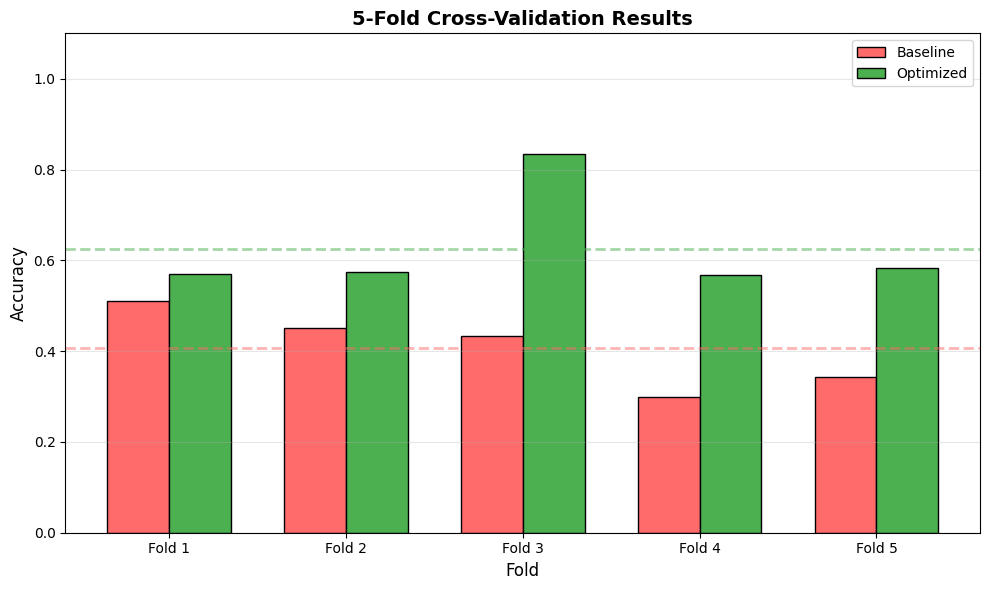

{'baseline_scores': [0.51, 0.45, 0.43329999999999996, 0.3, 0.3439],
 'optimized_scores': [0.57,
  0.575,
  0.8332999999999999,
  0.5667,
  0.5832999999999999],
 'baseline_mean': np.float64(0.40743999999999997),
 'baseline_std': np.float64(0.07560334913216478),
 'optimized_mean': np.float64(0.62566),
 'optimized_std': np.float64(0.10397066124633428),
 'improvement': np.float64(0.21822000000000003)}

In [88]:
def run_cross_validation(full_dataset: pd.DataFrame, k_folds: int = 5):
    """
    Run k-fold cross-validation for more reliable metrics on small datasets.
    
    This is especially useful when you have < 30 examples.
    """
    print("\n" + "="*70)
    print(f"RUNNING {k_folds}-FOLD CROSS-VALIDATION")
    print("="*70)
    print("\nThis provides more reliable estimates with small datasets.")
    print("Each fold uses different examples for training/validation.\n")
    
    # Create DSPy examples
    examples = create_dspy_examples(full_dataset)
    
    # Shuffle
    np.random.seed(config.random_seed)
    indices = np.random.permutation(len(examples))
    examples_shuffled = [examples[i] for i in indices]
    
    # Split into folds
    fold_size = len(examples) // k_folds
    folds = []
    for i in range(k_folds):
        start_idx = i * fold_size
        end_idx = start_idx + fold_size if i < k_folds - 1 else len(examples)
        folds.append(examples_shuffled[start_idx:end_idx])
    
    baseline_scores = []
    optimized_scores = []
    
    for fold_idx in range(k_folds):
        print(f"\n--- Fold {fold_idx + 1}/{k_folds} ---")
        
        # Create train/val split
        valset = folds[fold_idx]
        trainset = [ex for i, fold in enumerate(folds) if i != fold_idx for ex in fold]
        
        print(f"  Train: {len(trainset)}, Val: {len(valset)}")
        
        # Create and evaluate baseline
        baseline = MotifExtractorModule()
        evaluator = Evaluate(devset=valset, metric=motif_accuracy_metric, num_threads=1, display_progress=False, display_table=0)
        baseline_score_result = evaluator(baseline)
        # Note: EvaluationResult returns percentage (0-100), divide by 100 for proper ratio
        baseline_score = float(baseline_score_result) / 100 if hasattr(baseline_score_result, '__float__') else baseline_score_result
        baseline_scores.append(baseline_score)
        
        # Optimize and evaluate
        optimizer = BootstrapFewShot(
            metric=motif_accuracy_metric,
            max_bootstrapped_demos=config.max_bootstrapped_demos,
            max_labeled_demos=config.max_labeled_demos,
        )
        
        optimized = optimizer.compile(baseline, trainset=trainset)
        optimized_score_result = evaluator(optimized)
        # Note: EvaluationResult returns percentage (0-100), divide by 100 for proper ratio
        optimized_score = float(optimized_score_result) / 100 if hasattr(optimized_score_result, '__float__') else optimized_score_result
        optimized_scores.append(optimized_score)
        
        print(f"  Baseline: {baseline_score:.2%}, Optimized: {optimized_score:.2%}, Δ: {optimized_score - baseline_score:+.2%}")
    
    # Calculate statistics
    baseline_mean = np.mean(baseline_scores)
    baseline_std = np.std(baseline_scores)
    optimized_mean = np.mean(optimized_scores)
    optimized_std = np.std(optimized_scores)
    
    print("\n" + "="*70)
    print("CROSS-VALIDATION RESULTS")
    print("="*70)
    
    print(f"\nBaseline (Unoptimized):")
    print(f"  Mean accuracy: {baseline_mean:.2%} ± {baseline_std:.2%}")
    
    print(f"\nOptimized (Few-shot):")
    print(f"  Mean accuracy: {optimized_mean:.2%} ± {optimized_std:.2%}")
    
    improvement_mean = optimized_mean - baseline_mean
    print(f"\nMean improvement: {improvement_mean:+.2%}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(k_folds)
    width = 0.35
    
    ax.bar(x - width/2, baseline_scores, width, label='Baseline', color='#FF6B6B', edgecolor='black')
    ax.bar(x + width/2, optimized_scores, width, label='Optimized', color='#4CAF50', edgecolor='black')
    
    # Add mean lines
    ax.axhline(baseline_mean, color='#FF6B6B', linestyle='--', linewidth=2, alpha=0.5)
    ax.axhline(optimized_mean, color='#4CAF50', linestyle='--', linewidth=2, alpha=0.5)
    
    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'{k_folds}-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Fold {i+1}' for i in range(k_folds)])
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'baseline_scores': baseline_scores,
        'optimized_scores': optimized_scores,
        'baseline_mean': baseline_mean,
        'baseline_std': baseline_std,
        'optimized_mean': optimized_mean,
        'optimized_std': optimized_std,
        'improvement': improvement_mean
    }
    
run_cross_validation(full_dataset)
